In [270]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd=".."
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes
import math
import os
from analysis_misc_functions import *

In [271]:
results_folder = wd+"/simulations/effect_of_heading_plus_radial/store_results/flocking/"
list_of_folder_ids= glob.glob(results_folder+"*")
list_of_folder_ids= [i[len(results_folder):] for i in list_of_folder_ids]
list_of_folder_ids= np.sort(list_of_folder_ids)
list_of_folder_ids_pruned= []
for folder_id in list_of_folder_ids:
    all_results = glob.glob(results_folder+str(folder_id)+'/*.simresults')
    if len(all_results)==0:
        continue
    list_of_folder_ids_pruned.append(folder_id)

list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids_pruned]
list_of_folder_ids_array_version= [(n[0][1:],n[1][1:]) for n in list_of_folder_ids_array_version]
list_of_folder_ids_array_version= np.array([(float(n[0]), float(n[1])) for n in list_of_folder_ids_array_version])

group_sizes= [5,10,20,30,50,75]

In [272]:
list_of_folder_ids

array(["(1, 1.5707963267948966, 'flocking')",
       "(1, 4.71238898038469, 'flocking')",
       "(2, 1.5707963267948966, 'flocking')",
       "(2, 4.71238898038469, 'flocking')",
       "(3, 1.5707963267948966, 'flocking')",
       "(3, 4.71238898038469, 'flocking')",
       "(4, 1.5707963267948966, 'flocking')",
       "(4, 4.71238898038469, 'flocking')",
       "(5, 1.5707963267948966, 'flocking')",
       "(5, 4.71238898038469, 'flocking')",
       "(6, 1.5707963267948966, 'flocking')",
       "(6, 4.71238898038469, 'flocking')",
       "(7, 1.5707963267948966, 'flocking')",
       "(7, 4.71238898038469, 'flocking')"], dtype='<U35')

In [273]:
list_of_folder_ids_array_version

array([[1.        , 1.57079633],
       [1.        , 4.71238898],
       [2.        , 1.57079633],
       [2.        , 4.71238898],
       [3.        , 1.57079633],
       [3.        , 4.71238898],
       [4.        , 1.57079633],
       [4.        , 4.71238898],
       [5.        , 1.57079633],
       [5.        , 4.71238898],
       [6.        , 1.57079633],
       [6.        , 4.71238898]])

In [274]:
folder_id= list_of_folder_ids[0]
all_results = glob.glob(results_folder+folder_id+'/*.simresults')
some_results =random.sample(all_results, int(len(all_results)*1.0))
all_results

["../simulations/effect_of_heading_plus_radial/store_results/flocking/(1, 1.5707963267948966, 'flocking')/heading_plus_radial_flocking_a48bc041-e9f0-4e5f-9a95-43571cfe182d_95894322_.simresults",
 "../simulations/effect_of_heading_plus_radial/store_results/flocking/(1, 1.5707963267948966, 'flocking')/heading_plus_radial_flocking_a7f7cede-94a9-4024-800f-26f7d1051794_771617163_.simresults",
 "../simulations/effect_of_heading_plus_radial/store_results/flocking/(1, 1.5707963267948966, 'flocking')/heading_plus_radial_flocking_e9e0e6fc-ae8c-4440-9107-737a8c558add_532980269_.simresults",
 "../simulations/effect_of_heading_plus_radial/store_results/flocking/(1, 1.5707963267948966, 'flocking')/heading_plus_radial_flocking_ac818af3-1c17-4913-80b9-8e03f2b9839c_342450096_.simresults",
 "../simulations/effect_of_heading_plus_radial/store_results/flocking/(1, 1.5707963267948966, 'flocking')/heading_plus_radial_flocking_3138fc15-c0d5-4029-91ed-c6d8b5a3b132_521739512_.simresults",
 "../simulations/effe

In [275]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}

In [276]:
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]

In [277]:
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')
task_type= input('What type of analysis is this?')

In [278]:
what_to_do

'rerun'

In [279]:
if what_to_do == 'rerun':
    array_containing_all_simulation_datasets_raw = []
    iterant=0
    yyyymmdd = dt.datetime.now()
    timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
    make_dir(task_type+'_data'+timestamp+"/")
    for folder_id in list_of_folder_ids_pruned:
        all_results = glob.glob(results_folder+str(folder_id)+'/*.simresults')
        some_results =random.sample(all_results, int(len(all_results)*1.0))
        if len(some_results)==0:
            continue
        
        %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
        # print(extracted_simdata)
        echoes_heard = []
        group_size = []
        group_diameter = []
        nearest_3nbrs = []
        nbr_detection_range = []
        uuid = []
        seed = []
        param_ids = []
        parameter_values = []
        echo_levels = []
        detection_angle = []
        for each in extracted_simdata:
            for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                    nearest_3nbrs, nbr_detection_range,
                                                    uuid, seed, param_ids, parameter_values,
                                                    echo_levels, detection_angle]):
                list_to_append.append(variable)
        simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                        'group_size':group_size,
                                        'group_diameter':group_diameter,
                                        'nearest_neighbour_distance':nearest_3nbrs,
                                        'nbrs_detected_distance':nbr_detection_range,
                                        'uuid':uuid,
                                        'seed':seed,
                                        'paramset_id':param_ids,
                                        'parameters_joint':parameter_values,
                                        'echo_levels':echo_levels,
                                        'detection_azimuth':detection_angle})
        column_names = keyword_arguments['variables_to_extract']

        for each in column_names:
            simulation_data[each] = np.nan

        %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
        

        simulation_data["focal_bat"]= len(simulation_data)*[list_of_folder_ids_array_version[iterant]]

        ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
        data_store = pd.HDFStore(task_type+'_data'+timestamp+'/'+folder_id+'.h5')
        data_store['simulation_data'] = simulation_data
        data_store.close()

        array_containing_all_simulation_datasets_raw.append(simulation_data)
        iterant+=1
        
if what_to_do == 'reanalyse':
    # show all datasets in the folder
    data_stores_in_folder = glob.glob(task_type+'_*]')

    datastores_by_index = pd.DataFrame(data={'data_stores':data_stores_in_folder})
    print(datastores_by_index)
    # user-inputs dataset choice:
    which_dataset = int(input('Give the index of the dataset you want to'))
    print()
    # load a pre-exisiting dataset
    #load the saved data 
    list_of_h5_files_in_folder= making_glob_work_properly(datastores_by_index["data_stores"][which_dataset])
    # print(list_of_h5_files_in_folder); print("./"+datastores_by_index["data_stores"][which_dataset]+'/*')
    array_containing_all_simulation_datasets_raw = []
    list_of_folder_ids_pruned, list_of_folder_ids_array_version= run_while_reanalysis_to_change_folder_ids(list_of_h5_files_in_folder)
    for h5_file in list_of_h5_files_in_folder:
        data_load = pd.HDFStore("./"+datastores_by_index["data_stores"][which_dataset]+'/'+h5_file)
        simulation_data = data_load['simulation_data']
        array_containing_all_simulation_datasets_raw.append(simulation_data)
        data_load.close()

# else:
#     raise IOError('Invalid input given!!')

100%|██████████| 600/600 [00:01<00:00, 515.82it/s]
/tmp/ipykernel_99366/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 58 ms, sys: 4.16 ms, total: 62.2 ms
Wall time: 1.4 s
CPU times: user 34.5 ms, sys: 0 ns, total: 34.5 ms
Wall time: 34.6 ms


100%|██████████| 600/600 [00:00<00:00, 1523.07it/s]
/tmp/ipykernel_99366/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 57.1 ms, sys: 2.09 ms, total: 59.2 ms
Wall time: 648 ms
CPU times: user 33.6 ms, sys: 0 ns, total: 33.6 ms
Wall time: 33.7 ms


100%|██████████| 501/501 [00:00<00:00, 1862.99it/s]
/tmp/ipykernel_99366/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


...

100%|██████████| 100/100 [00:00<00:00, 1566.36it/s]
/tmp/ipykernel_99366/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 13.5 ms, sys: 2.05 ms, total: 15.5 ms
Wall time: 123 ms
CPU times: user 6.53 ms, sys: 0 ns, total: 6.53 ms
Wall time: 6.54 ms


100%|██████████| 100/100 [00:00<00:00, 1495.70it/s]


CPU times: user 17.4 ms, sys: 1.97 ms, total: 19.4 ms
Wall time: 133 ms
CPU times: user 7.25 ms, sys: 0 ns, total: 7.25 ms
Wall time: 7.26 ms


/tmp/ipykernel_99366/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


In [280]:
array_containing_all_simulation_datasets_pruned= []
for group_size in group_sizes:
    for simulation_data in array_containing_all_simulation_datasets_raw:
        indices_given_group_size= simulation_data["group_size"]==group_size
        if len(simulation_data[indices_given_group_size])<100:
            array_containing_all_simulation_datasets_pruned.append(simulation_data[~indices_given_group_size])

In [281]:
array_containing_all_simulation_datasets=[]

for simulation_data in array_containing_all_simulation_datasets_raw:
    if False: #simulation_data["focal_bat"][0][0]==5.0 or simulation_data["focal_bat"][0][0]==6.0:
        continue
    else:
        array_containing_all_simulation_datasets.append(simulation_data)



In [282]:
array_containing_all_simulation_datasets

[     nbrs_detected  group_size  group_diameter  \
 0                9          30        3.757645   
 1                6          20        3.031395   
 2                1          75        6.136048   
 3                4           5        1.109786   
 4                9          10        2.046821   
 ..             ...         ...             ...   
 595              0          75        6.059533   
 596              0          75        6.011546   
 597              2           5        1.376624   
 598              8          30        3.806283   
 599              4          20        2.888521   
 
                             nearest_neighbour_distance  \
 0    [0.5032796028273375, 0.5401503435495915, 0.627...   
 1    [0.504209398199835, 0.5086669901079603, 0.7776...   
 2    [0.5063404235377366, 0.53792361086603, 0.55281...   
 3    [0.5049501299319225, 0.7838304904387061, 1.028...   
 4    [0.512194231484915, 0.5591270878101161, 0.5618...   
 ..                             

In [283]:
unique_angles_in_dataset= np.unique(list_of_folder_ids_array_version[:,1])
list_containing_simulated_data_sorted_by_angles= {}
for angle in unique_angles_in_dataset:
    list_containing_simulated_data_sorted_by_angles[angle]= []
    sublist_true_false_labels= list_of_folder_ids_array_version[:,1]==angle
    sublist_given_angle= passing_true_false_indices_through_lists(array_containing_all_simulation_datasets_raw, sublist_true_false_labels)
    list_containing_simulated_data_sorted_by_angles[angle].append(sublist_given_angle)

0
2
4
6
8
10
1
3
5
7
9
11


1.5707963267948966


/tmp/ipykernel_99366/2100935761.py:9: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(simulation_data['group_size'],


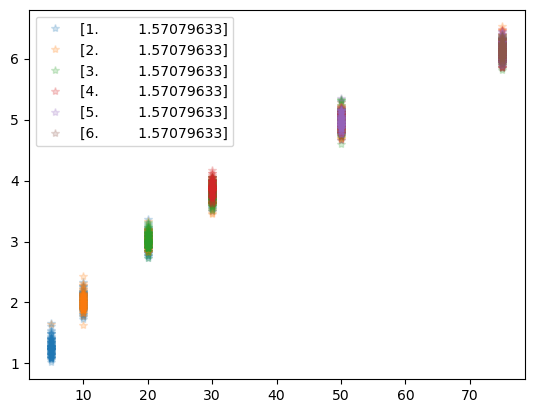

4.71238898038469


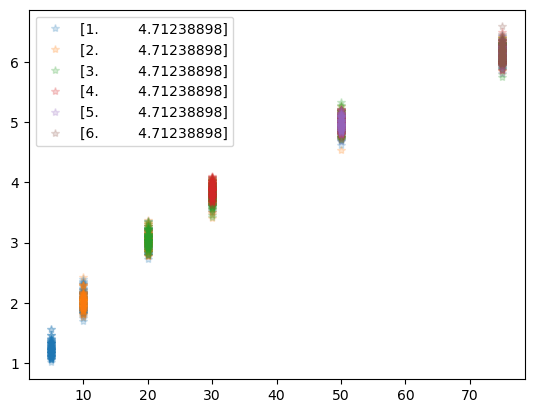

In [284]:
%matplotlib inline
i=0
for angle in list_containing_simulated_data_sorted_by_angles.keys():
    print(angle)
    subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]

    for simulation_data in subset_given_angle:
        if len(simulation_data)!=0:
            plt.plot(simulation_data['group_size'],
                        simulation_data['group_diameter'], 
                    '*',label=simulation_data["focal_bat"][0],alpha=0.2)
        i+=1
    plt.legend()
    plt.show()

In [285]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat'],
      dtype='object')

In [286]:
by_minspacing = simulation_data.groupby('min_spacing')
nearest_nbr_dist = {}
for spacing, df in by_minspacing:
    nearest_nbr_distances = df['nearest_neighbour_distance'].reset_index(drop=True)
    nearest_nbr_dist[spacing] = np.concatenate(nearest_nbr_distances)
nearest_nbr_dists_for_plot = [nearest_nbr_dist[0.5]]

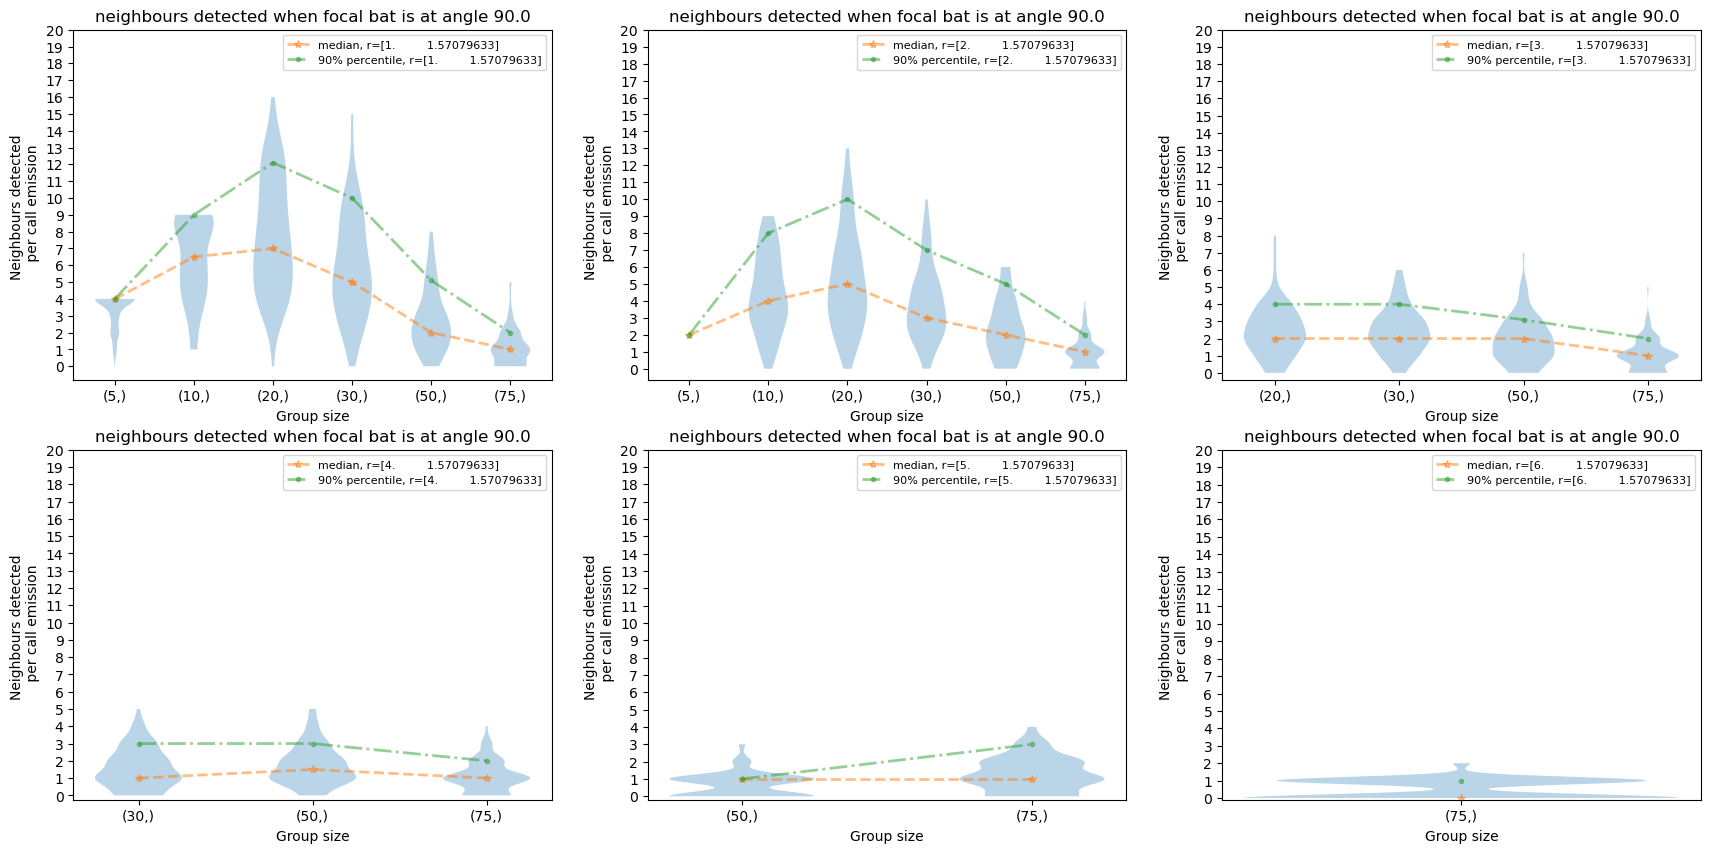

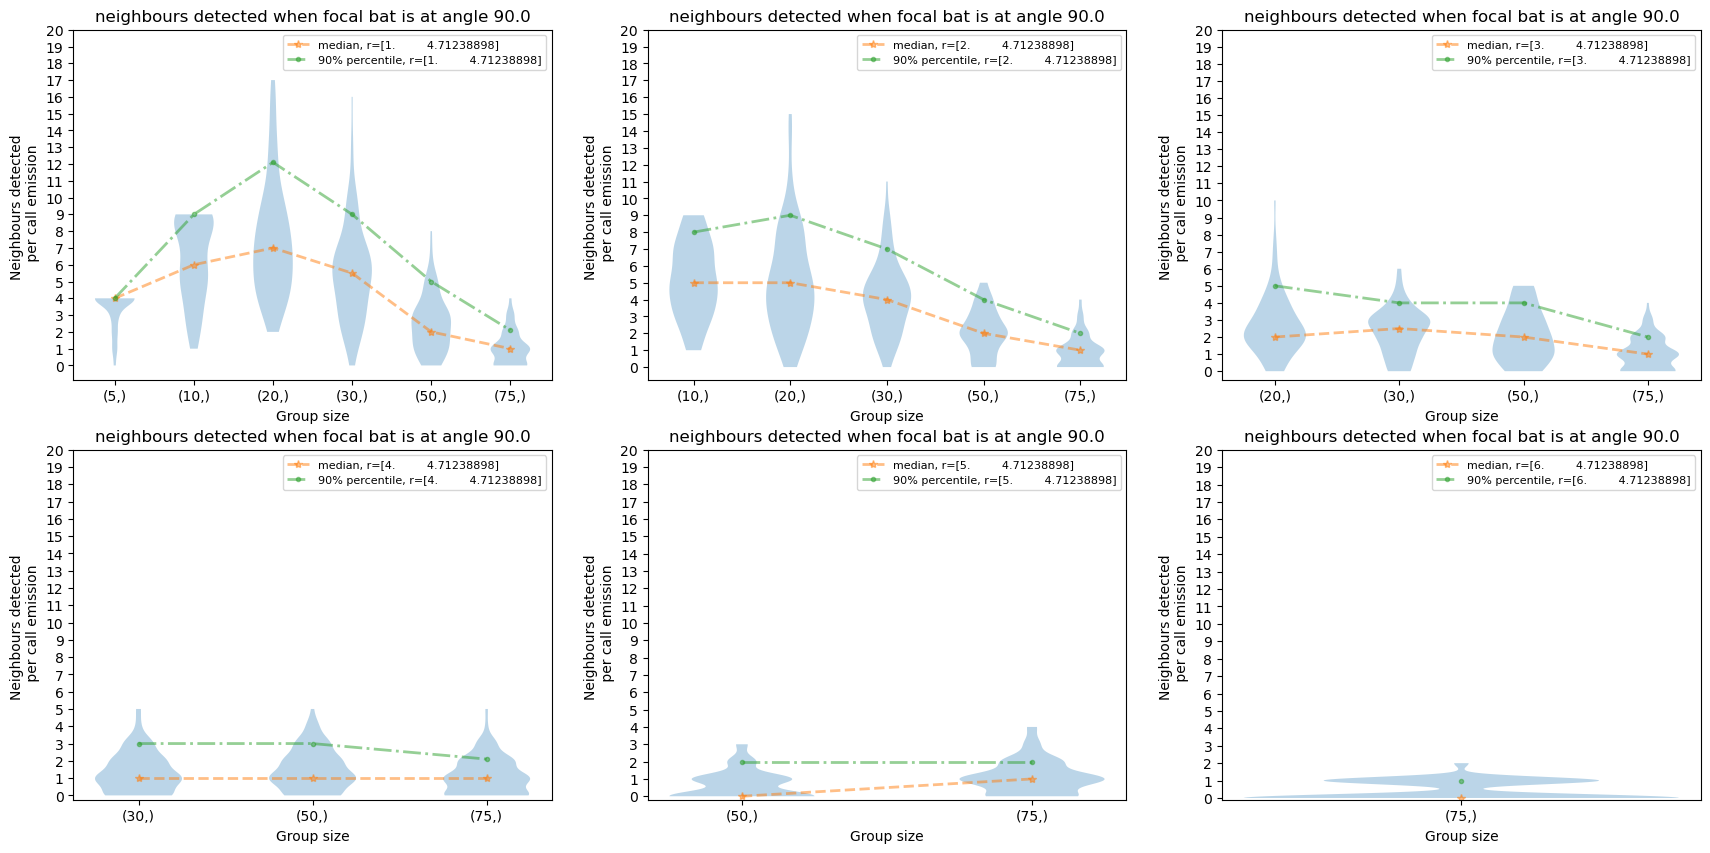

In [287]:
iterant1_axis=0
# fig, axs = plt.subplots(1,3, figsize=(27,9))


for angle in list_containing_simulated_data_sorted_by_angles.keys():
        subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]; iterant2_color=0
        colors=["blue", "red", "green", "black"]
        plt.figure(figsize=(21,10))
        i=1
        for simulation_data in subset_given_angle:
                data_by_groupsize = simulation_data.groupby(['group_size'])
                nbrs_detected_data = {}
                nbrs_detected_data['num_nbrs'] = []
                nbrs_detected_data['median_num_nbrs'] = []
                nbrs_detected_data['90%ile_num_nbrs'] = []
                groupsizes= []
                for groupsize, dataframe in data_by_groupsize:
                        groupsizes.append(groupsize)
                        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

                breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
                nbrs_detected_data['median_num_nbrs']

                # plt.figure(figsize=(7,3.42))
                plt.subplot(2,3,i)
                plt.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
                plt.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
                        '--*',linewidth=2, alpha=0.5,label="median, r="+str(simulation_data["focal_bat"][0]))#'median')
                # print(np.arange(1,len(groupsizes)))
                plt.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                        '-..',linewidth=2, alpha=0.5, label="90% percentile, r="+str(simulation_data["focal_bat"][0]))#label='90%ile')
                # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
                plt.yticks(np.arange(0,21,1))
                plt.xticks(range(1,len(groupsizes)+1),groupsizes[:])
                plt.legend(fontsize=8)
                plt.ylabel('Neighbours detected \n per call emission', fontsize=10)
                plt.xlabel('Group size', fontsize=10)
                # # plt.ylim(0,20)

                # axs[i].tight_layout()
                plt.title("neighbours detected when focal bat is at angle "+str(np.degrees(np.pi/2)))
                iterant2_color+=1; i+=1
                
        iterant1_axis+=1
                # plt.savefig('Figure2_groupsize_1200dpi.pdf',
                #         bbox_inches='tight', pad_inches=0.05, format='pdf', dpi=1200)
        
        # print(groupsizes); print(nbrs_detected_data['median_num_nbrs'])

# Verticle transect

moving from $(0.75, \frac {3pi}{2})$ to $(0.75, \frac {pi}{2})$ [r, theta] is similar to moving in a ($x=0$) transect centered at the centermost bat.
Note: All the heading vectors are in 90 degree direction ( $\pm$ 10 degree)

In [288]:
transect_subsets= [[6, 3*np.pi/2],[5, 3*np.pi/2],[4, 3*np.pi/2],[3, 3*np.pi/2],[2, 3*np.pi/2],[1, 3*np.pi/2],[1, np.pi/2],[2, np.pi/2], [3, np.pi/2], [4, np.pi/2], [5, np.pi/2], [6, np.pi/2]]
iterant_transect=0
sublist_of_simulation_data_intransect=[]
for r_theta in transect_subsets:
    for simulation_data in array_containing_all_simulation_datasets:
        if (simulation_data["focal_bat"][0]==r_theta).all():
            sublist_of_simulation_data_intransect.append(simulation_data)    

sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1]     


In [289]:
len(sublist_of_simulation_data_intransect)
# len(transect_subsets)

12

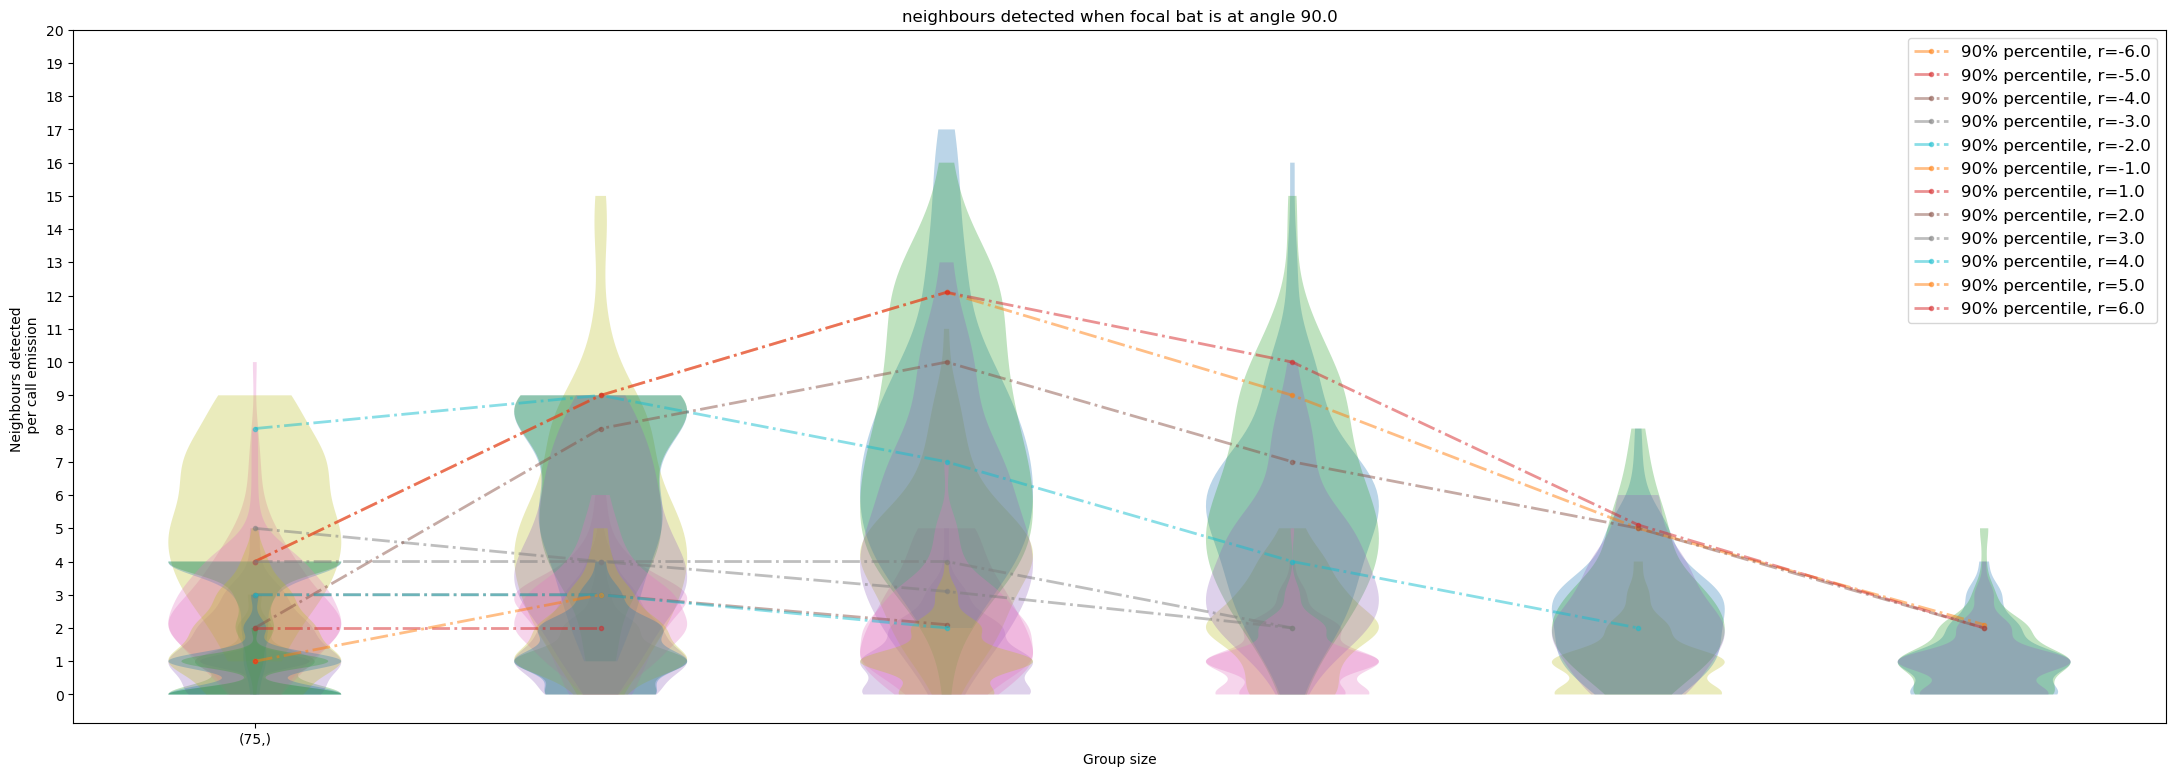

In [290]:
colors=["blue", "red", "green", "black", "orange", "cyan"]

fig, axs = plt.subplots(1,1, figsize=(27,9))
iterant2_color=0
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])
        nbrs_detected_data = {}
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        groupsizes= []
        for groupsize, dataframe in data_by_groupsize:
                groupsizes.append(groupsize)
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

        breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
        nbrs_detected_data['median_num_nbrs']

        # plt.figure(figsize=(7,3.42))
        # plt.subplot(1,2,i)
        
        axs.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
        # axs.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
        #         '--*',linewidth=2, alpha=0.5,label="median, r="+str(sign_based_on_distance_from_centermost_point[iterant2_color]*simulation_data["focal_bat"][0][0]), 
        #         color= colors[iterant2_color])#'median')
        # print(np.arange(1,len(groupsizes)))
        axs.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                '-..',linewidth=2, alpha=0.5, label="90% percentile, r="+str(sign_based_on_distance_from_centermost_point[iterant2_color]*simulation_data["focal_bat"][0][0])
                )#label='90%ile')
        # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
        axs.set_yticks(np.arange(0,21,1))
        axs.set_xticks(range(1,len(groupsizes)+1),groupsizes[:])
        axs.legend(fontsize=12)
        axs.set_ylabel('Neighbours detected \n per call emission', fontsize=10)
        axs.set_xlabel('Group size', fontsize=10)
        # # plt.ylim(0,20)

        # axs[i].tight_layout()
        axs.set_title("neighbours detected when focal bat is at angle "+str(np.degrees(simulation_data["focal_bat"][0][1])))
        iterant2_color+=1
plt.show()

separate the violin plots out for different group sizes to see clear differences between distance from center


/tmp/ipykernel_99366/721828577.py:18: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_99366/721828577.py:18: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_99366/721828577.py:18: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_99366/721828577.py:18: FutureWarning: When grouping 

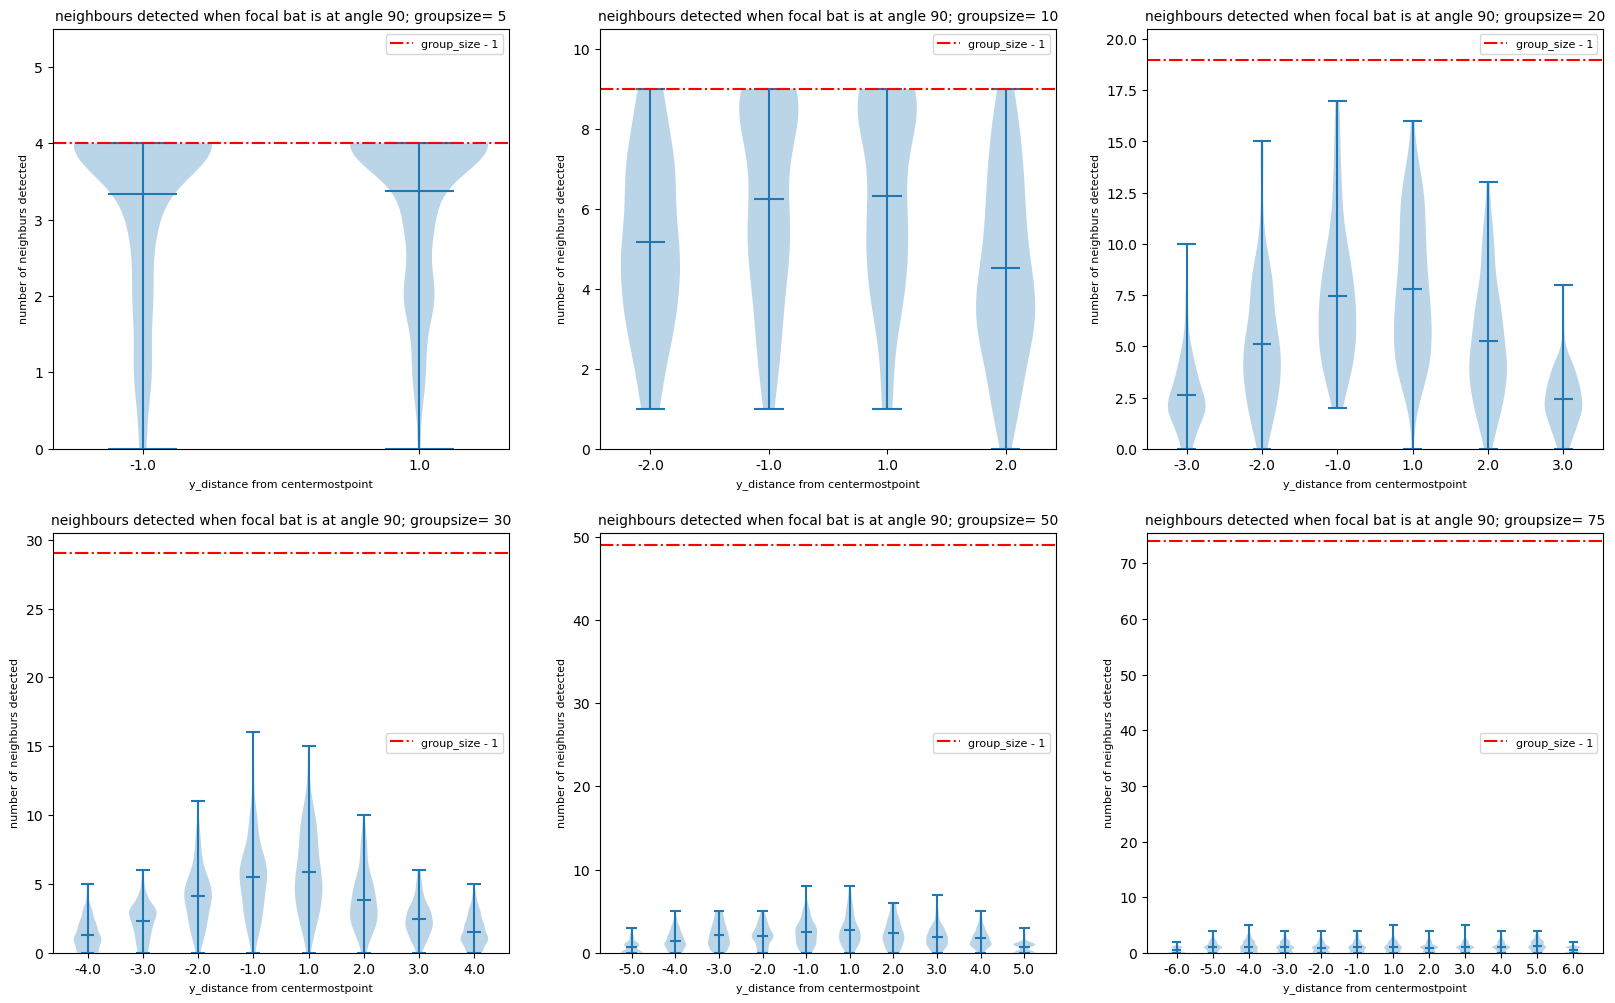

In [291]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=-1
    for simulation_data in sublist_of_simulation_data_intransect:
        iterant_sign+=1

        try:
            dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
            if len(dataframe["nbrs_detected"])!=100:
                continue
            nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
            nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
            nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))    
        except KeyError:
            continue
        x_ticks.append(sign_based_on_distance_from_centermost_point[iterant_sign]*simulation_data["focal_bat"][0][0])
    

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,len(x_ticks)+1),x_ticks)
    # plt.show()
    plt.ylim(0,group_size+0.5)
    plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    plt.legend(fontsize= "8")

    i+=1

Zooming into the plots to see finer differences between the diffrent violin plots

/tmp/ipykernel_99366/2747149107.py:17: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_99366/2747149107.py:17: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_99366/2747149107.py:17: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_99366/2747149107.py:17: FutureWarning: When group

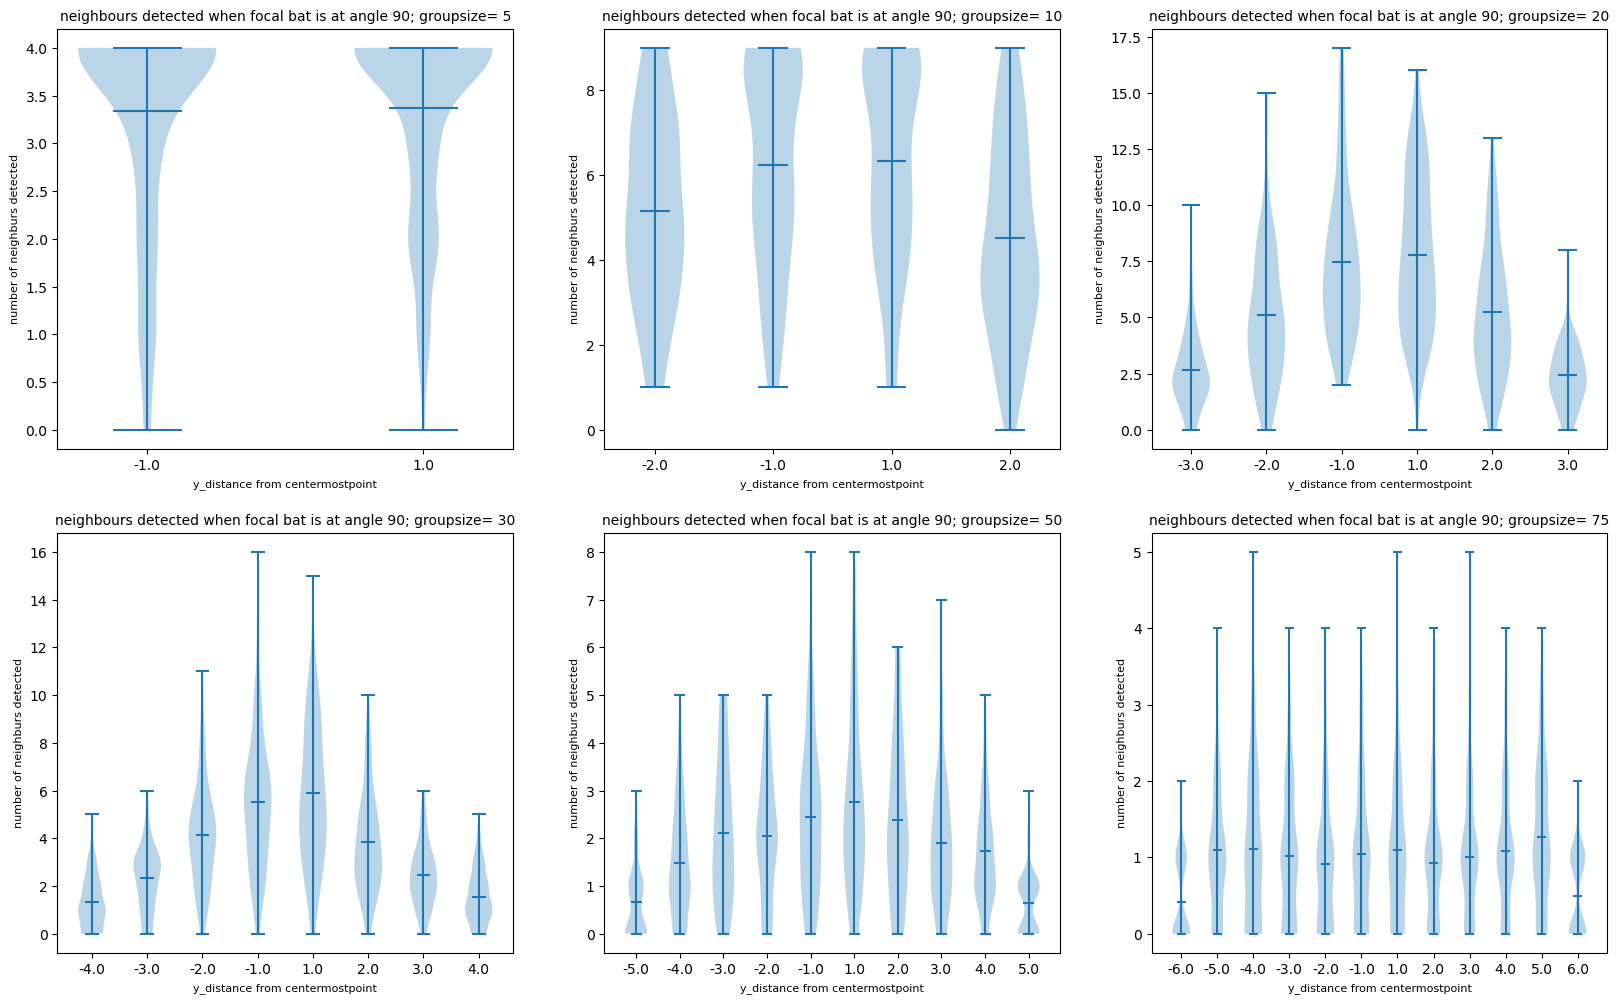

In [292]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=-1
    for simulation_data in sublist_of_simulation_data_intransect:
        iterant_sign+=1
        try:
            dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
            if len(dataframe["nbrs_detected"])<90:
                continue
            nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
            nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
            nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))    
        except KeyError:
            continue
        x_ticks.append(sign_based_on_distance_from_centermost_point[iterant_sign]*simulation_data["focal_bat"][0][0])

        

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,len(x_ticks)+1),x_ticks)
    # plt.show()
    # plt.ylim(0,group_size+0.5)
    # plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    # plt.legend(fontsize= "8")

    i+=1

The number of neighbours detected shows an increase with group size initially and then drops sharply down beyond 30 bats. 


### How does the probability of detecting at least one neighbour change with group size?

In [293]:
def calculate_geqNneighbour(num_detected_neighbours, N):
    '''Calculates the proportion of an array-like
    object that is >= N.
    
    '''
    geq_N = np.float64(np.sum(num_detected_neighbours>=N))
    if np.isnan(np.min(num_detected_neighbours)):
        return np.nan
    proportion_geq_N = geq_N/len(num_detected_neighbours)
    return(proportion_geq_N)

In [294]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat'],
      dtype='object')

In [295]:
sublist_of_simulation_data_intransect[1]

,nbrs_detected,group_size,group_diameter,nearest_neighbour_distance,nbrs_detected_distance,uuid,seed,paramset_id,parameters_joint,echo_levels,detection_azimuth,heading_variation,echocall_duration,atmospheric_attenuation,min_spacing,source_level,interpulse_interval,implement_shadowing,focal_bat
0,0,50,4.997660,"[0.6263248471955287, 0.7754339857633619, 0.829...",[],c8a1858b-90a6-4cc2-b323-dc52f32744b1,250148026,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
1,1,75,6.050261,"[0.5007342611583848, 0.5161353795445164, 0.843...",[0.5007342611583848],2003c5c1-0756-482a-8dcf-47338287ace7,298752205,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]",[71.31904182925966],[28.9433],flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
2,0,75,6.222022,"[0.7086936374505035, 0.8112404539776872, 0.850...",[],c12bf744-2aa9-4a35-a347-b9c52f443226,726994172,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
3,0,75,6.188365,"[0.5494934063079884, 0.7129601453803397, 0.725...",[],c33c750f-ac58-4b48-bcdf-e2f466f2c9c5,844078360,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
4,0,50,4.999874,"[0.574091227385354, 0.6332191517759197, 0.8838...",[],2e36f4e8-a497-4312-88f9-01b83a6499db,143209486,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1,50,4.685855,"[0.5804532779296975, 0.6221352673440339, 0.854...",[0.5804532779296975],dba44a41-112c-4653-ba0d-42a9b4710157,484913796,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]",[68.6140419037755],[1.7353],flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
196,3,50,4.881257,"[0.5788643474805947, 0.616328867146906, 0.8258...","[0.5788643474805947, 0.616328867146906, 0.8786...",12769e56-93ff-47fb-99b2-00eee2b60ca0,492589304,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]","[65.97905385807354, 55.96773384256382, 61.2338...","[-55.8313, -126.7414, -11.5731]",flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
197,0,50,5.141143,"[0.5586018798349673, 0.6211399970965492, 0.972...",[],0f0fadb2-3a3b-4ae1-a882-8ba9050a804e,728267297,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
198,0,50,5.001561,"[0.5434255181849875, 0.5467885524734666, 0.892...",[],1733a199-100c-4935-8309-932f52a0c924,544841096,flocking*0.0025*-1*0.5*100*0.1*True,"[flocking, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],flocking,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"


In [314]:
#store data
store_probability_of_detection_n_neighbour= {}
group_sizes= [5,10,20,30,50,75]
i=0
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])

        nbrs_detected_data = {}
        nbrs_detected_data["group_sizes"]= group_sizes
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        groupsizes= []

        for groupsize, dataframe in data_by_groupsize:
                if len(dataframe)<100:
                        continue
                groupsizes.append(groupsize[0])
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))
        nan_groupsizes= [i for i in group_sizes if i not in groupsizes]

        for nan_groupsize in nan_groupsizes:
                nbrs_detected_data['num_nbrs']= [np.nan, *nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['median_num_nbrs']= [np.nan, *nbrs_detected_data['median_num_nbrs']]
                nbrs_detected_data['90%ile_num_nbrs']= [np.nan, *nbrs_detected_data['90%ile_num_nbrs']]

        nbrs_detected_data['0neighbours'] = [ 1-calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_1neighbour'] = [ calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_2neighbour'] = [ calculate_geqNneighbour(each,2)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_3neighbour'] = [ calculate_geqNneighbour(each,3)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_4neighbour'] = [ calculate_geqNneighbour(each,4)  for each in nbrs_detected_data['num_nbrs']]

        nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_detected_distances'] = map(np.median, nbrs_detected_data['detected_distances'])
        nbrs_detected_data['90%ile_detected_distances'] = map(lambda X : np.percentile(X,90),
                                                        nbrs_detected_data['detected_distances'][:-1])

        nbrs_detected_data['neighbours_azimuth'] = [ np.concatenate(np.array(dataframe['detection_azimuth'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_neighbours_azimuth'] = [ np.median(each)  for each in nbrs_detected_data['neighbours_azimuth'] ]
        nbrs_detected_data['95%ile_neighbours_azimuth'] = [ np.percentile(each, 92.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]
        nbrs_detected_data['5%ile_neighbours_azimuth'] = [ np.percentile(each, 2.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]

        nbrs_detected_data['echolevels'] = [ np.concatenate(np.array(dataframe['echo_levels'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_echolevels'] = [ np.median(each) for each in nbrs_detected_data['echolevels']]
        nbrs_detected_data['5%ile_echolevels'] = [ np.percentile(each, 2.5) for each in nbrs_detected_data['echolevels'][:-1]]
        nbrs_detected_data['95%ile_echolevels'] = [ np.percentile(each, 97.5) for each in nbrs_detected_data['echolevels'][:-1]]

        for nan_groupsize in nan_groupsizes:
                nbrs_detected_data['detected_distances']= [np.nan, *nbrs_detected_data['detected_distances']]
                nbrs_detected_data['median_detected_distances']= [np.nan, *nbrs_detected_data['median_detected_distances']]
                nbrs_detected_data['90%ile_detected_distances']= [np.nan, *nbrs_detected_data['90%ile_detected_distances']]

                nbrs_detected_data['neighbours_azimuth']= [[np.nan], *nbrs_detected_data['neighbours_azimuth']]
                nbrs_detected_data['median_neighbours_azimuth']= [np.nan, *nbrs_detected_data['median_neighbours_azimuth']]
                nbrs_detected_data['5%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['5%ile_neighbours_azimuth']]
                nbrs_detected_data['95%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['95%ile_neighbours_azimuth']]

                nbrs_detected_data['echolevels']= [[np.nan], *nbrs_detected_data['echolevels']]
                nbrs_detected_data['median_echolevels']= [np.nan, *nbrs_detected_data['median_echolevels']]
                nbrs_detected_data['5%ile_echolevels']= [np.nan, *nbrs_detected_data['5%ile_echolevels']]
                nbrs_detected_data['95%ile_echolevels']= [np.nan, *nbrs_detected_data['95%ile_echolevels']]
                
        
        store_probability_of_detection_n_neighbour[simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]]= nbrs_detected_data
        i+=1

In [297]:
nan_groupsize

50

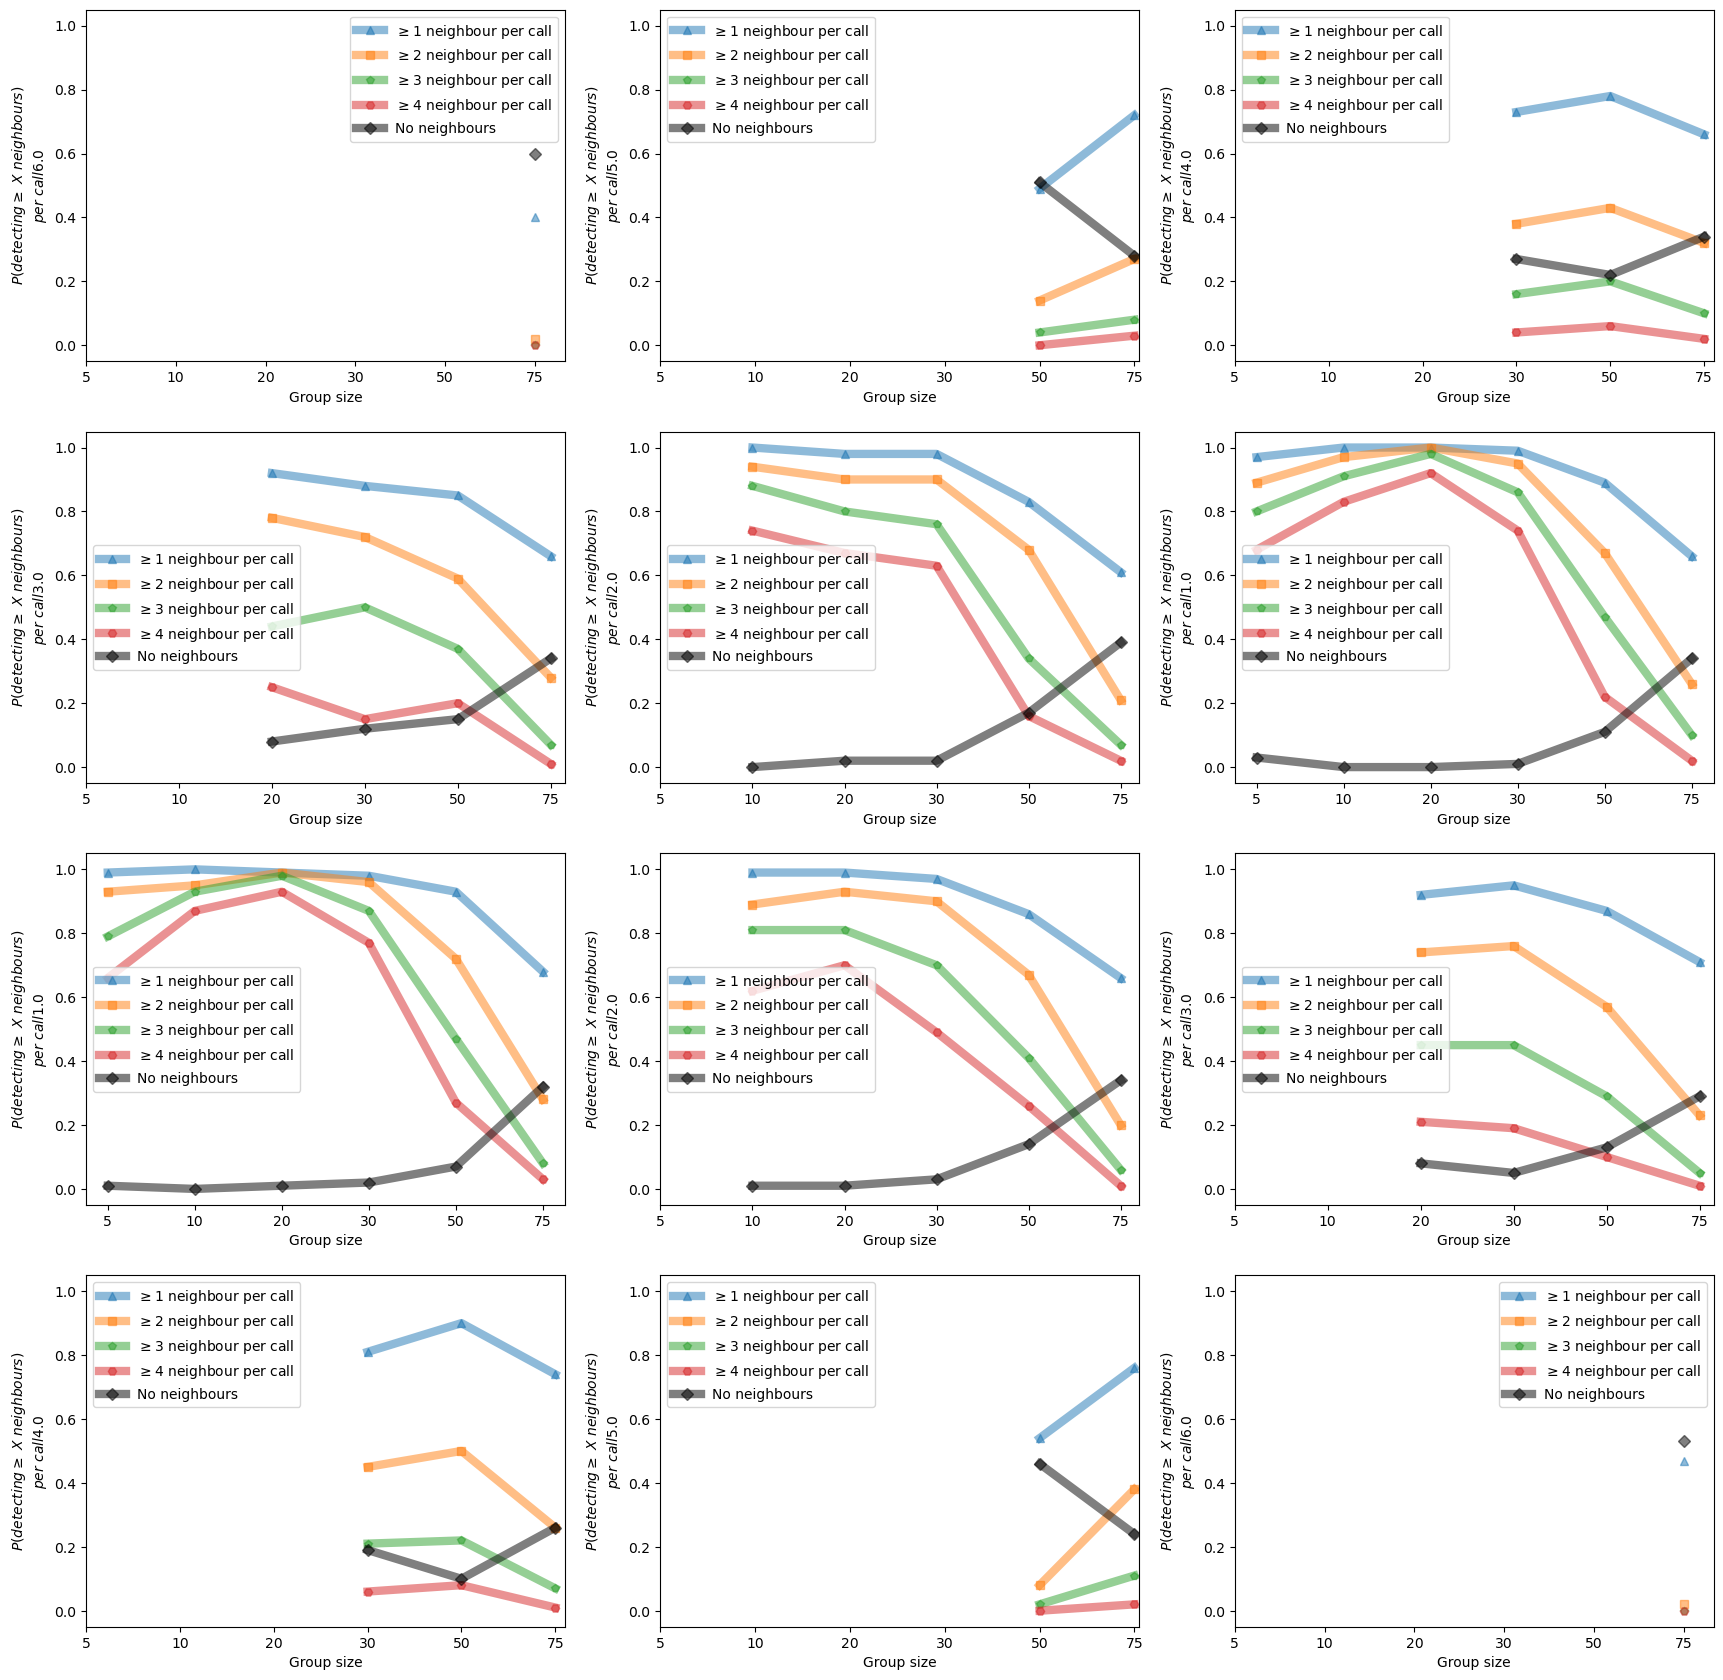

In [315]:
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(sublist_of_simulation_data_intransect)/number_of_columns))
plt.figure(figsize= (21,21))
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])
        groupsizes= group_sizes

        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], '-^', linewidth=6, alpha=0.5, label='$\geq1$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], '-s', linewidth=6, alpha=0.5, label='$\geq2$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], '-p', linewidth=6, alpha=0.5, label='$\geq3$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], '-H', linewidth=6, alpha=0.5, label='$\geq4$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], '-Dk', linewidth=6, alpha=0.5, label='No neighbours')

        plt.yticks(fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1),
                groupsizes,fontsize=10)
        plt.legend()
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["focal_bat"][0][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)
        
        i+=1

In [299]:
nbrs_detected_data['geq_1neighbour']

[nan, nan, nan, nan, nan, np.float64(0.47)]

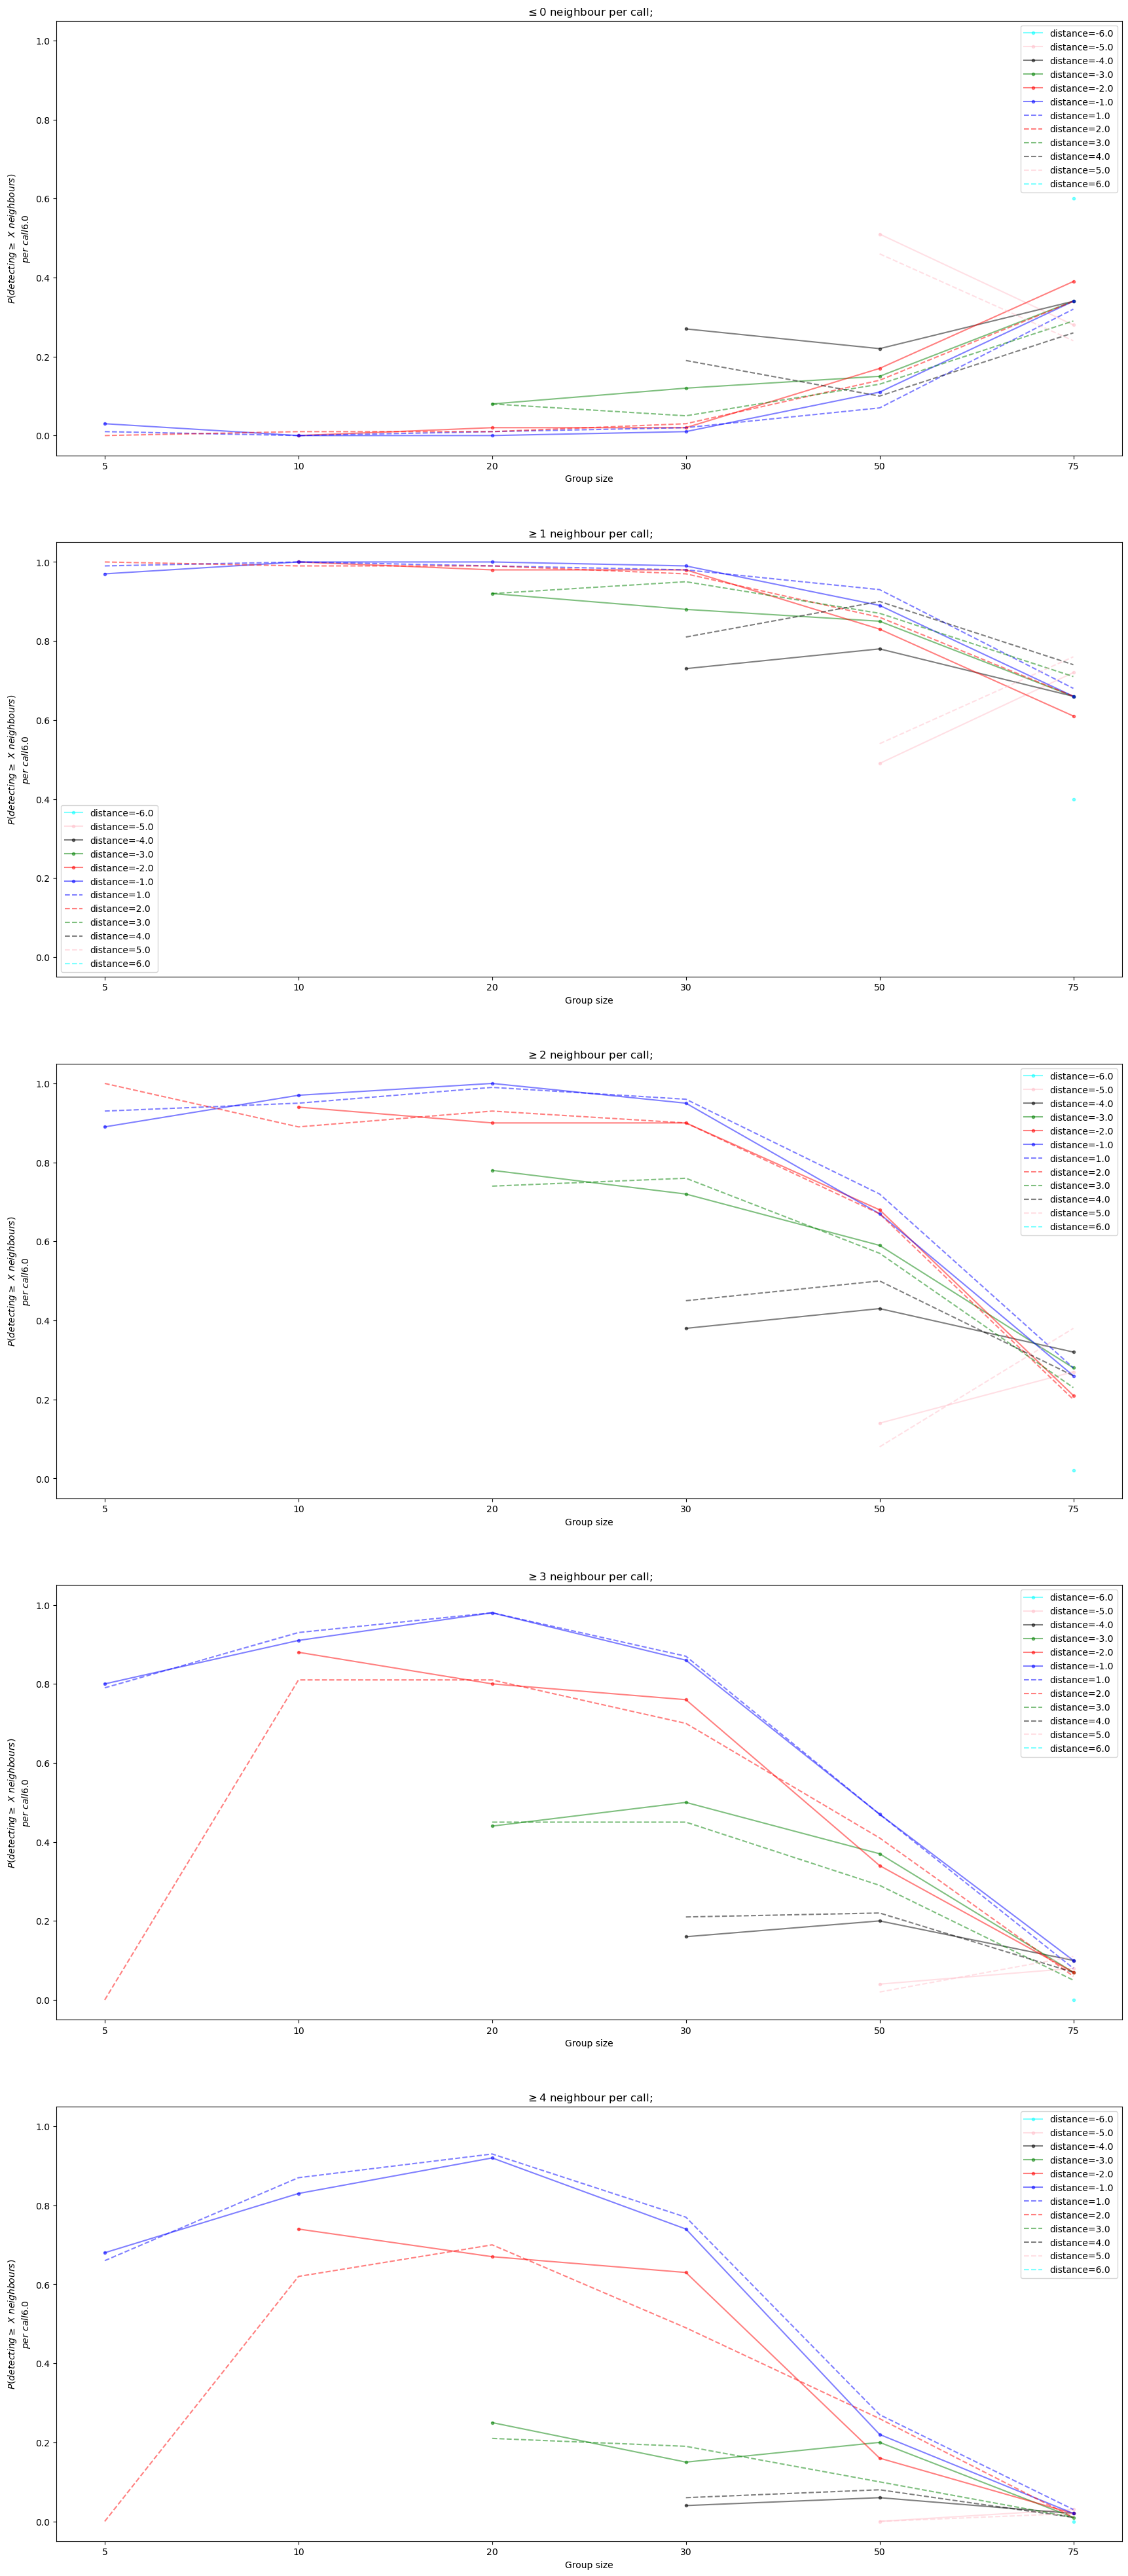

In [312]:
number_of_neighbours_atleast_detected= [0,1,2,3,4]
i=0; 
number_of_columns=1; number_of_rows= int(np.ceil(len(number_of_neighbours_atleast_detected)/number_of_columns))
plt.figure(figsize= (21,50))

for simulation_data in sublist_of_simulation_data_intransect:

        groupsizes= group_sizes

        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        if sign_based_on_distance_from_centermost_point[i]<0:
                ls= ".-"
        else:
                ls= "--"

        plt.subplot(number_of_rows,number_of_columns,2)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        
        plt.subplot(number_of_rows,number_of_columns,3)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        
        plt.subplot(number_of_rows,number_of_columns,4)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        
        plt.subplot(number_of_rows,number_of_columns,5)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        
        plt.subplot(number_of_rows,number_of_columns,1)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        i+=1
for i in range(1,6):
        if i==1:
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$\leq{i-1}$ neighbour per call;")
        else: 
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$\geq{i-1}$ neighbour per call;")
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["focal_bat"][0][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)


-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
1.0
2.0
3.0
4.0
5.0
6.0


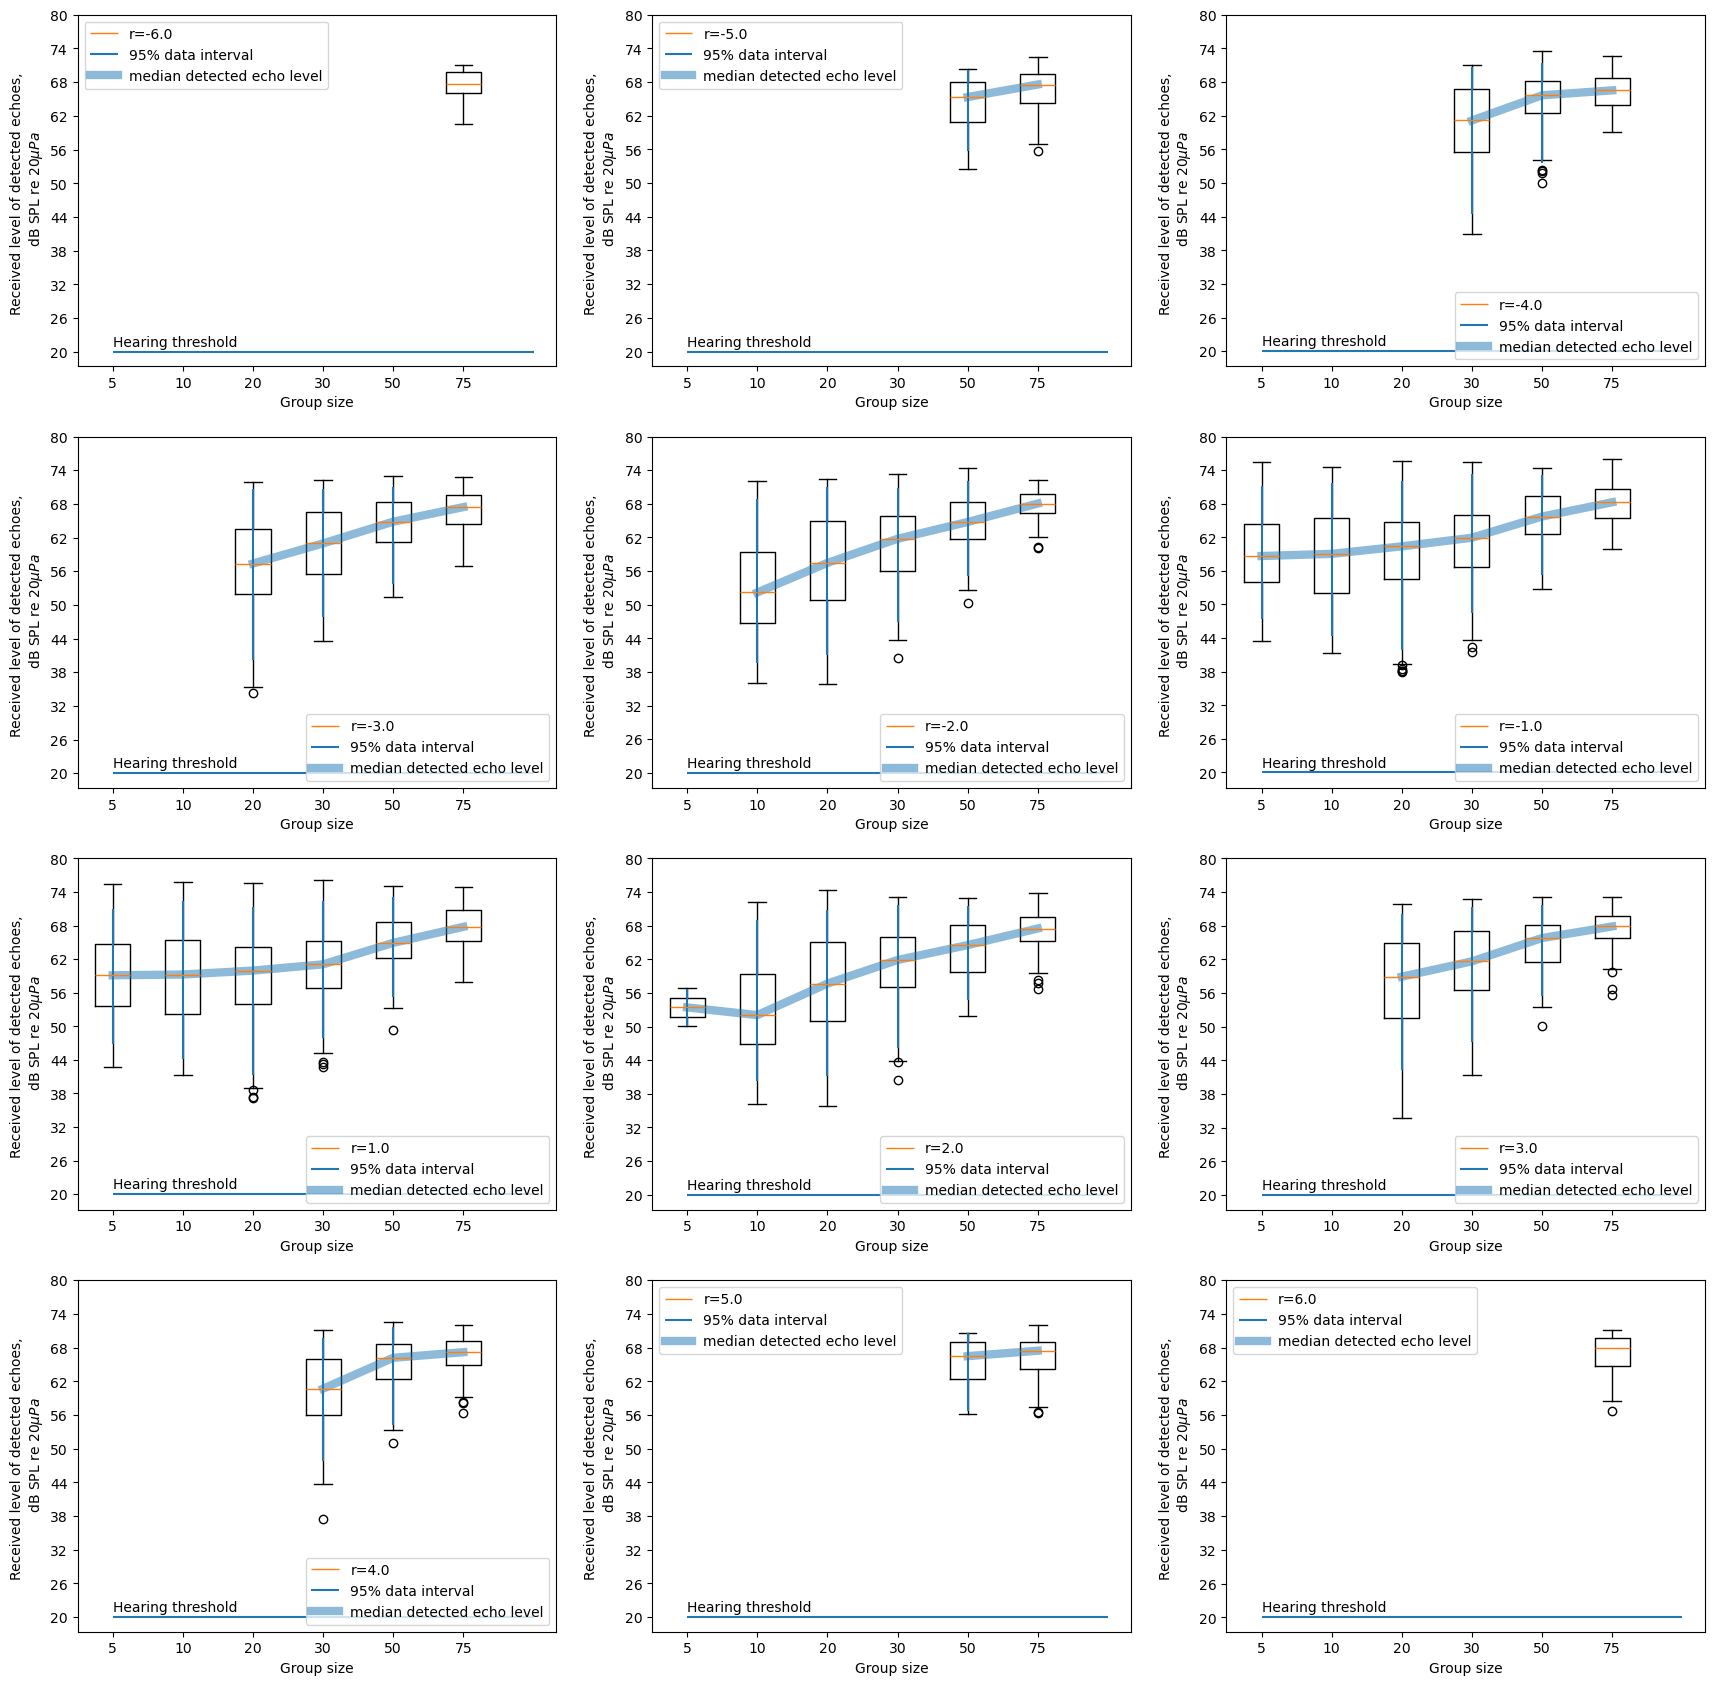

In [301]:

i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(sublist_of_simulation_data_intransect)/number_of_columns))
plt.figure(figsize= (21,21))
for simulation_data in sublist_of_simulation_data_intransect:
        groupsizes= group_sizes
        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(nbrs_detected_data['echolevels'][:], label=f"r={key_for_dict}");
        plt.vlines(range(1,len(nbrs_detected_data['95%ile_echolevels'])+1),nbrs_detected_data['5%ile_echolevels'],
                                                                        nbrs_detected_data['95%ile_echolevels'],
                                label='95% data interval')

        plt.plot(range(1,len(groupsizes)+1), nbrs_detected_data['median_echolevels'], linewidth=6, alpha=0.5,
                label='median detected echo level')
        plt.ylabel('Received level of detected echoes, \n dB SPL re 20$\mu Pa$',
                                                fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1), groupsizes, fontsize=10)
        plt.hlines([20],1,len(groupsizes)+1)
        plt.yticks(np.arange(20,86,6),np.arange(20,86,6), fontsize=10)
        plt.text(1,21,'Hearing threshold', fontsize=10)
        plt.xlabel('Group size', fontsize=10)
        plt.legend()
        print(key_for_dict)
        i+=1

/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that

6.0
6.0
6.0
6.0
6.0
6.0


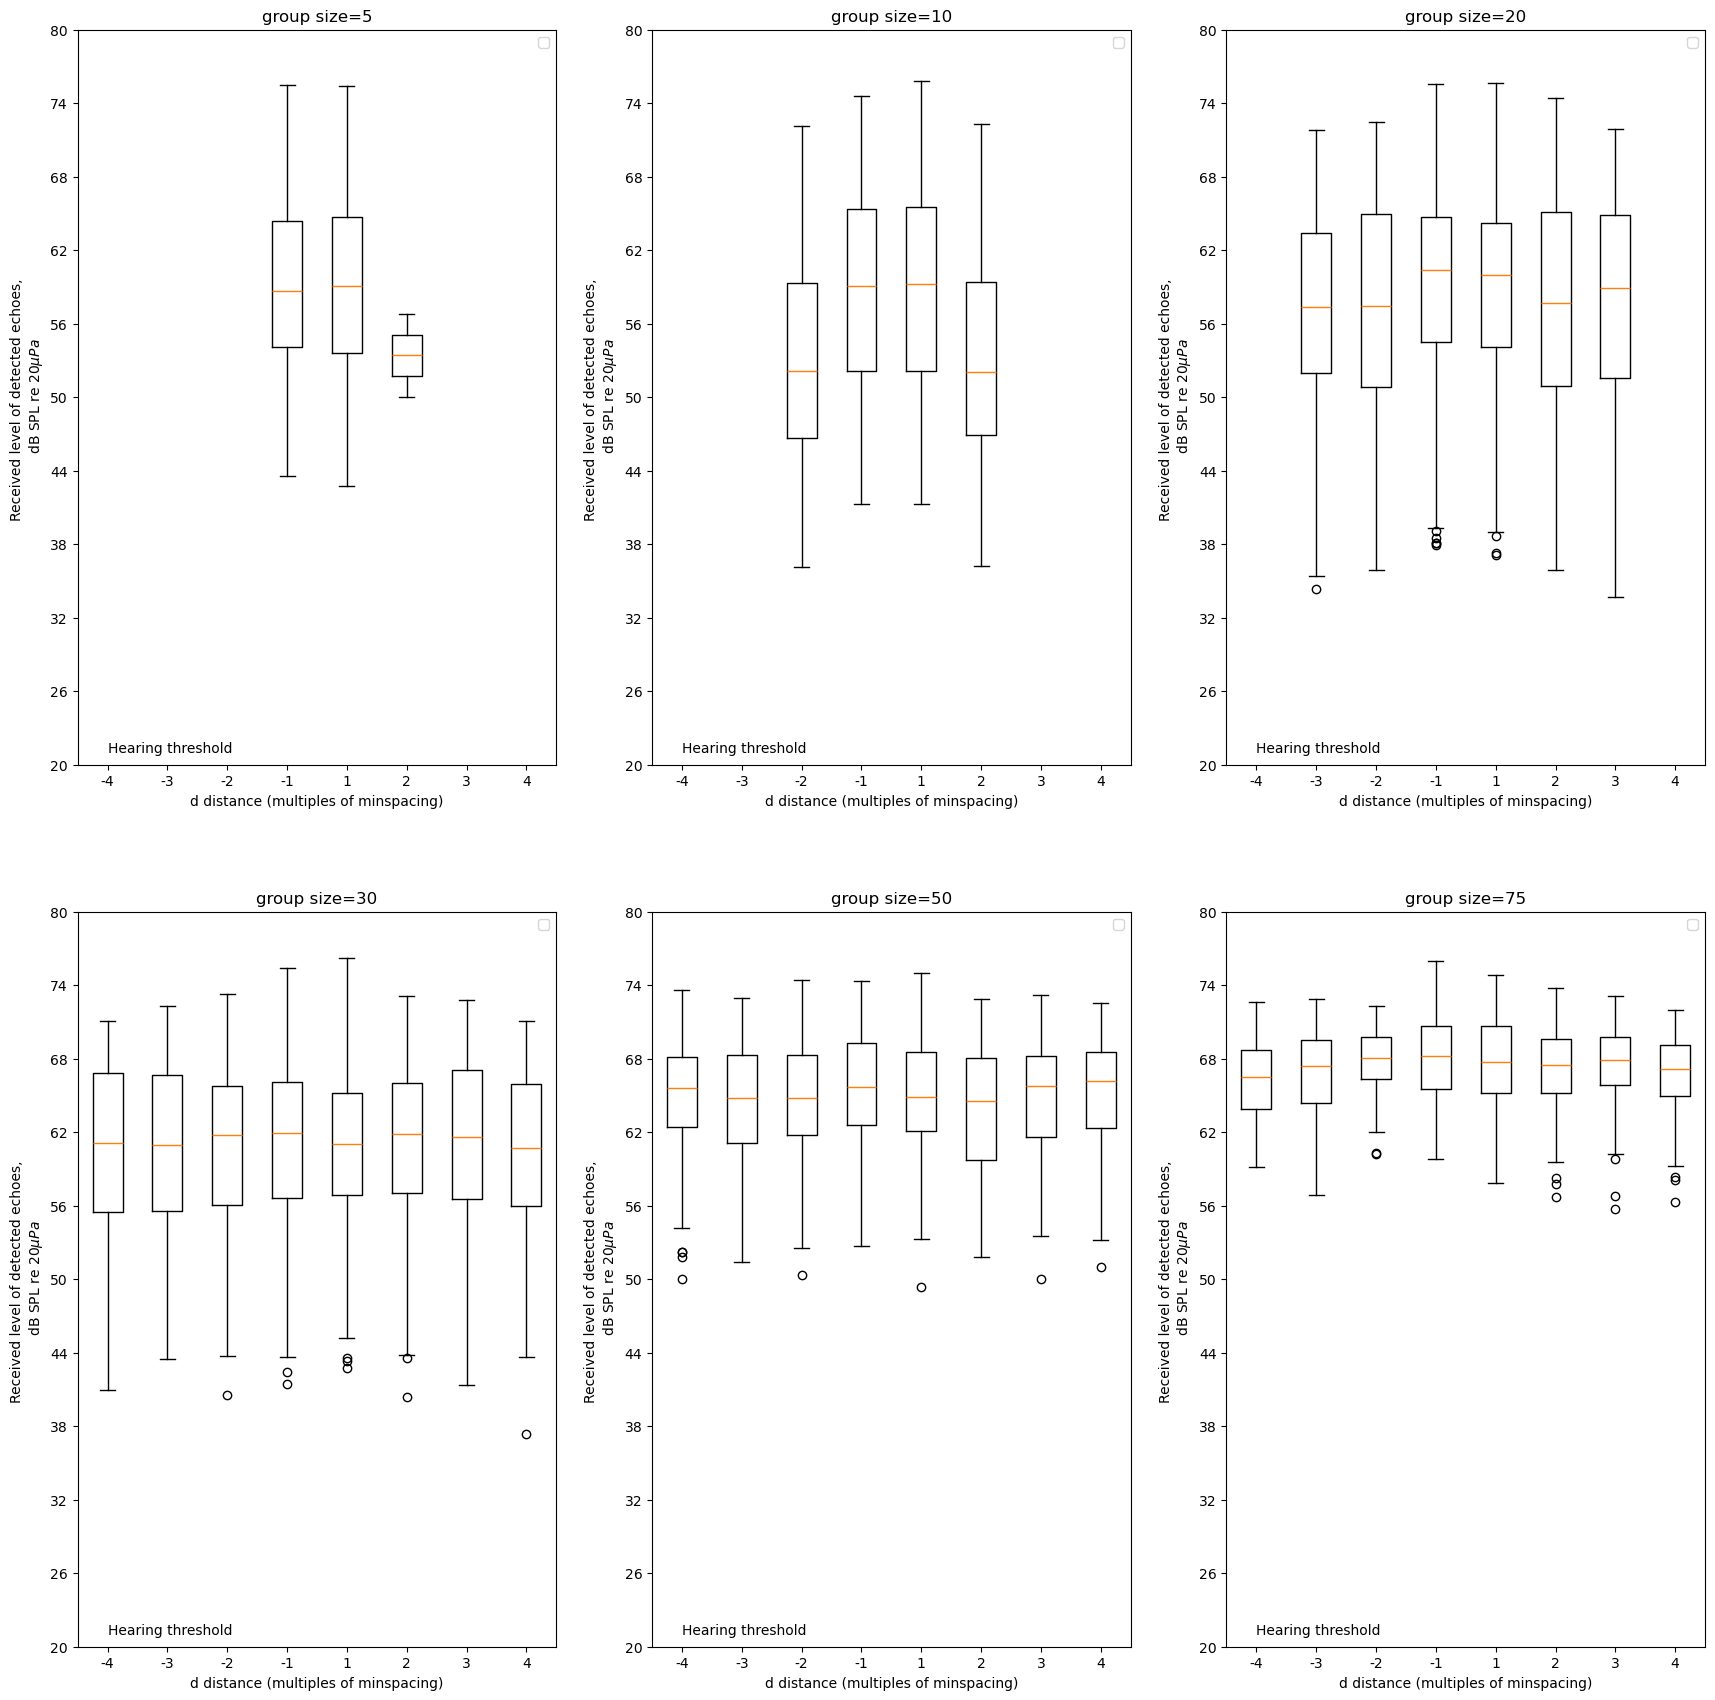

In [302]:
i=0; 
d_distances_along_transect= [-4,-3,-2,-1,1,2,3,4]
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
for group_size in group_sizes:
        array_storing_info_for_plot= []
        iterant_sign=-1
        x_ticks=[]
        for key in d_distances_along_transect:
                iterant_sign+=1
                nbrs_detected_data= store_probability_of_detection_n_neighbour[key]
                data_to_store= nbrs_detected_data['echolevels'][group_sizes.index(group_size)]
                array_storing_info_for_plot.append(data_to_store)
                x_ticks.append(key)

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(array_storing_info_for_plot);

        plt.ylabel('Received level of detected echoes, \n dB SPL re 20$\mu Pa$',
                                                fontsize=10)
        plt.xticks(np.arange(1,len(x_ticks)+1), x_ticks, fontsize=10)
        plt.yticks(np.arange(20,86,6),np.arange(20,86,6), fontsize=10)
        plt.text(1,21,'Hearing threshold', fontsize=10)
        plt.xlabel('d distance (multiples of minspacing)', fontsize=10)
        plt.legend()
        plt.title(f"group size={group_size}")
        print(key_for_dict)
        i+=1

-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
1.0
2.0
3.0
4.0
5.0
6.0


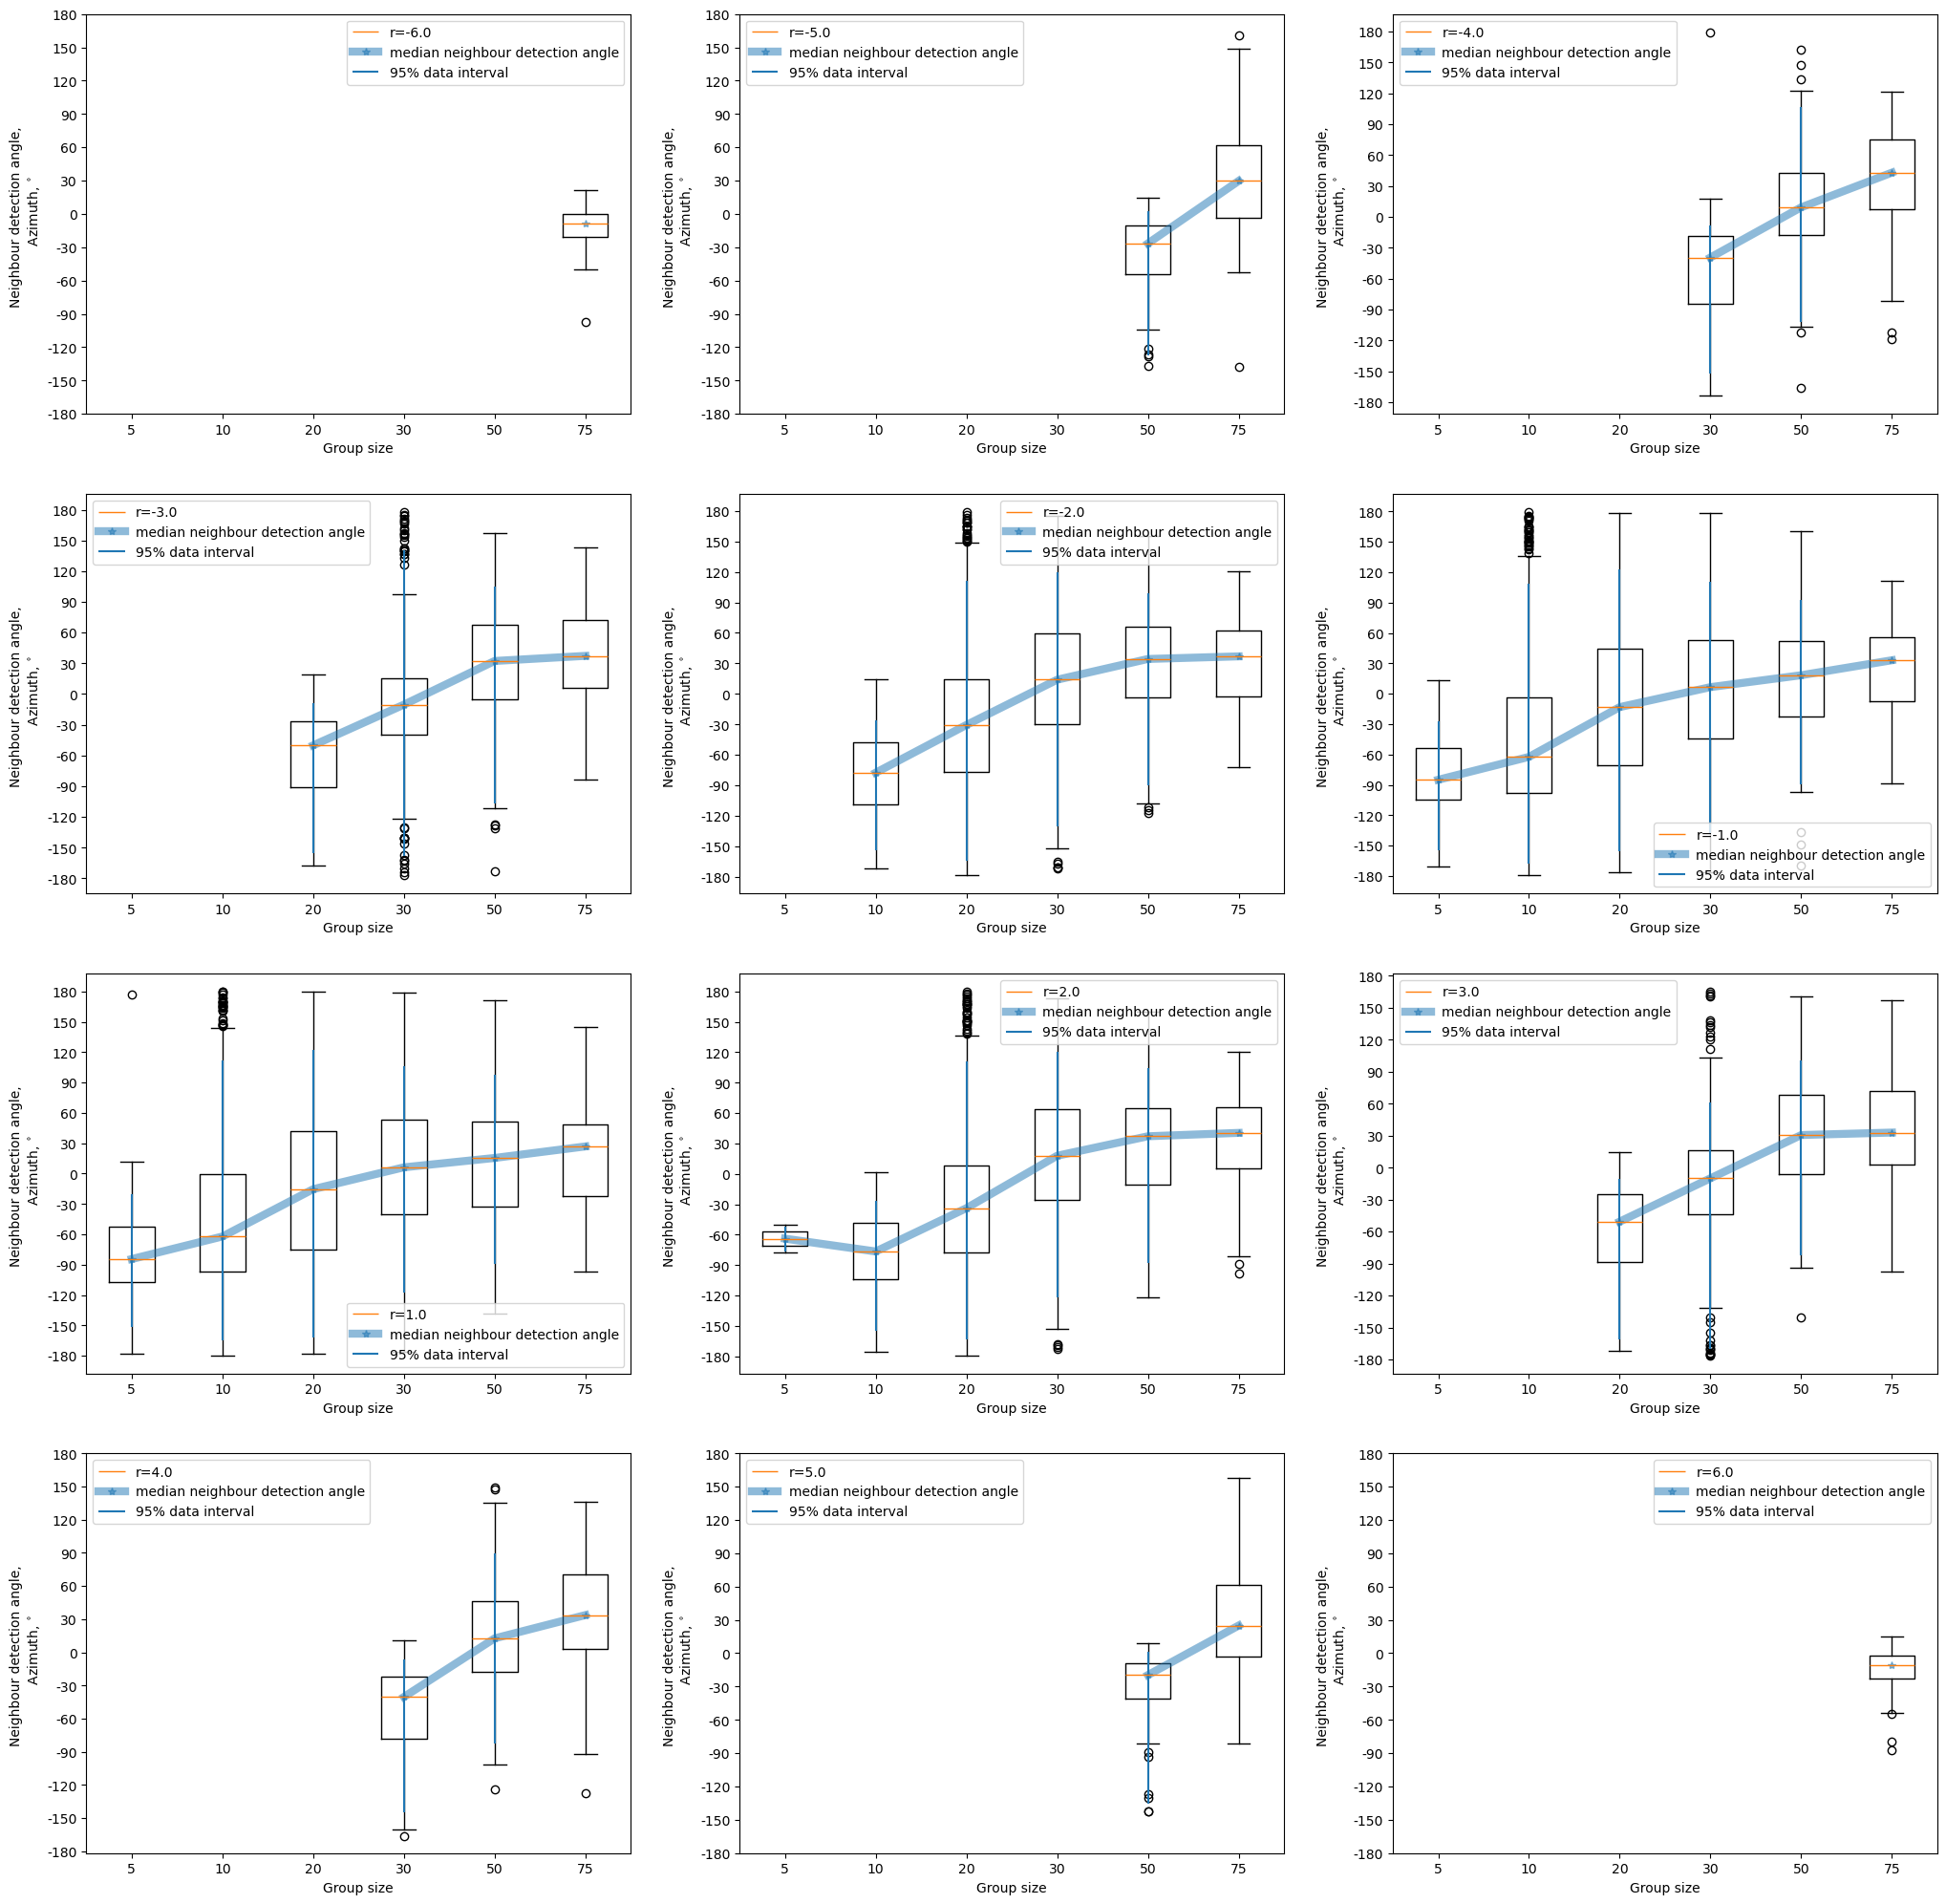

In [303]:
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(sublist_of_simulation_data_intransect)/number_of_columns))
plt.figure(figsize= (25,25))
for simulation_data in sublist_of_simulation_data_intransect:
        groupsizes= group_sizes
        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(nbrs_detected_data['neighbours_azimuth'][:], label=f"r={key_for_dict}")
        plt.plot(np.arange(1,7), nbrs_detected_data['median_neighbours_azimuth'], '-*', linewidth=6,
                        alpha=0.5, label='median neighbour detection angle')
        plt.vlines(range(1,len(nbrs_detected_data['5%ile_neighbours_azimuth'])+1),nbrs_detected_data['5%ile_neighbours_azimuth'],
                nbrs_detected_data['95%ile_neighbours_azimuth'], label='95% data interval')
        #plt.plot(np.arange(1,8), nbrs_detected_data['95%ile_neighbours_azimuth'], 'g')
        #plt.plot(np.arange(1,8), nbrs_detected_data['5%ile_neighbours_azimuth'], 'g', label='95%  neighbour detection range')

        plt.yticks(np.arange(-180,210,30), np.arange(-180,210,30), fontsize=10)
        plt.xticks(np.arange(1,7), group_sizes, fontsize=10)
        plt.legend()
        plt.ylabel('Neighbour detection angle, \n  Azimuth, $^{\circ}$', fontsize=10)
        plt.xlabel('Group size', fontsize=10)


        print(key_for_dict)
        i+=1

(array([ 1.,  6.,  9., 20., 27., 42., 39., 31., 12.,  3.]),
 array([-140.3574 , -110.27132,  -80.18524,  -50.09916,  -20.01308,
          10.073  ,   40.15908,   70.24516,  100.33124,  130.41732,
         160.5034 ]),
 <BarContainer object of 10 artists>)

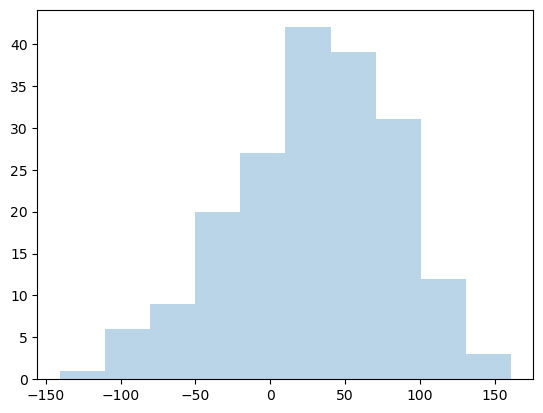

In [304]:
nbrs_detected_data= store_probability_of_detection_n_neighbour[3]
plt.hist(nbrs_detected_data['neighbours_azimuth'][4], alpha=0.3)
# print(np.sum(plt.hist(nbrs_detected_data['neighbours_azimuth'][6])[0]))

/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note

6.0
6.0
6.0
6.0
6.0


/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


6.0


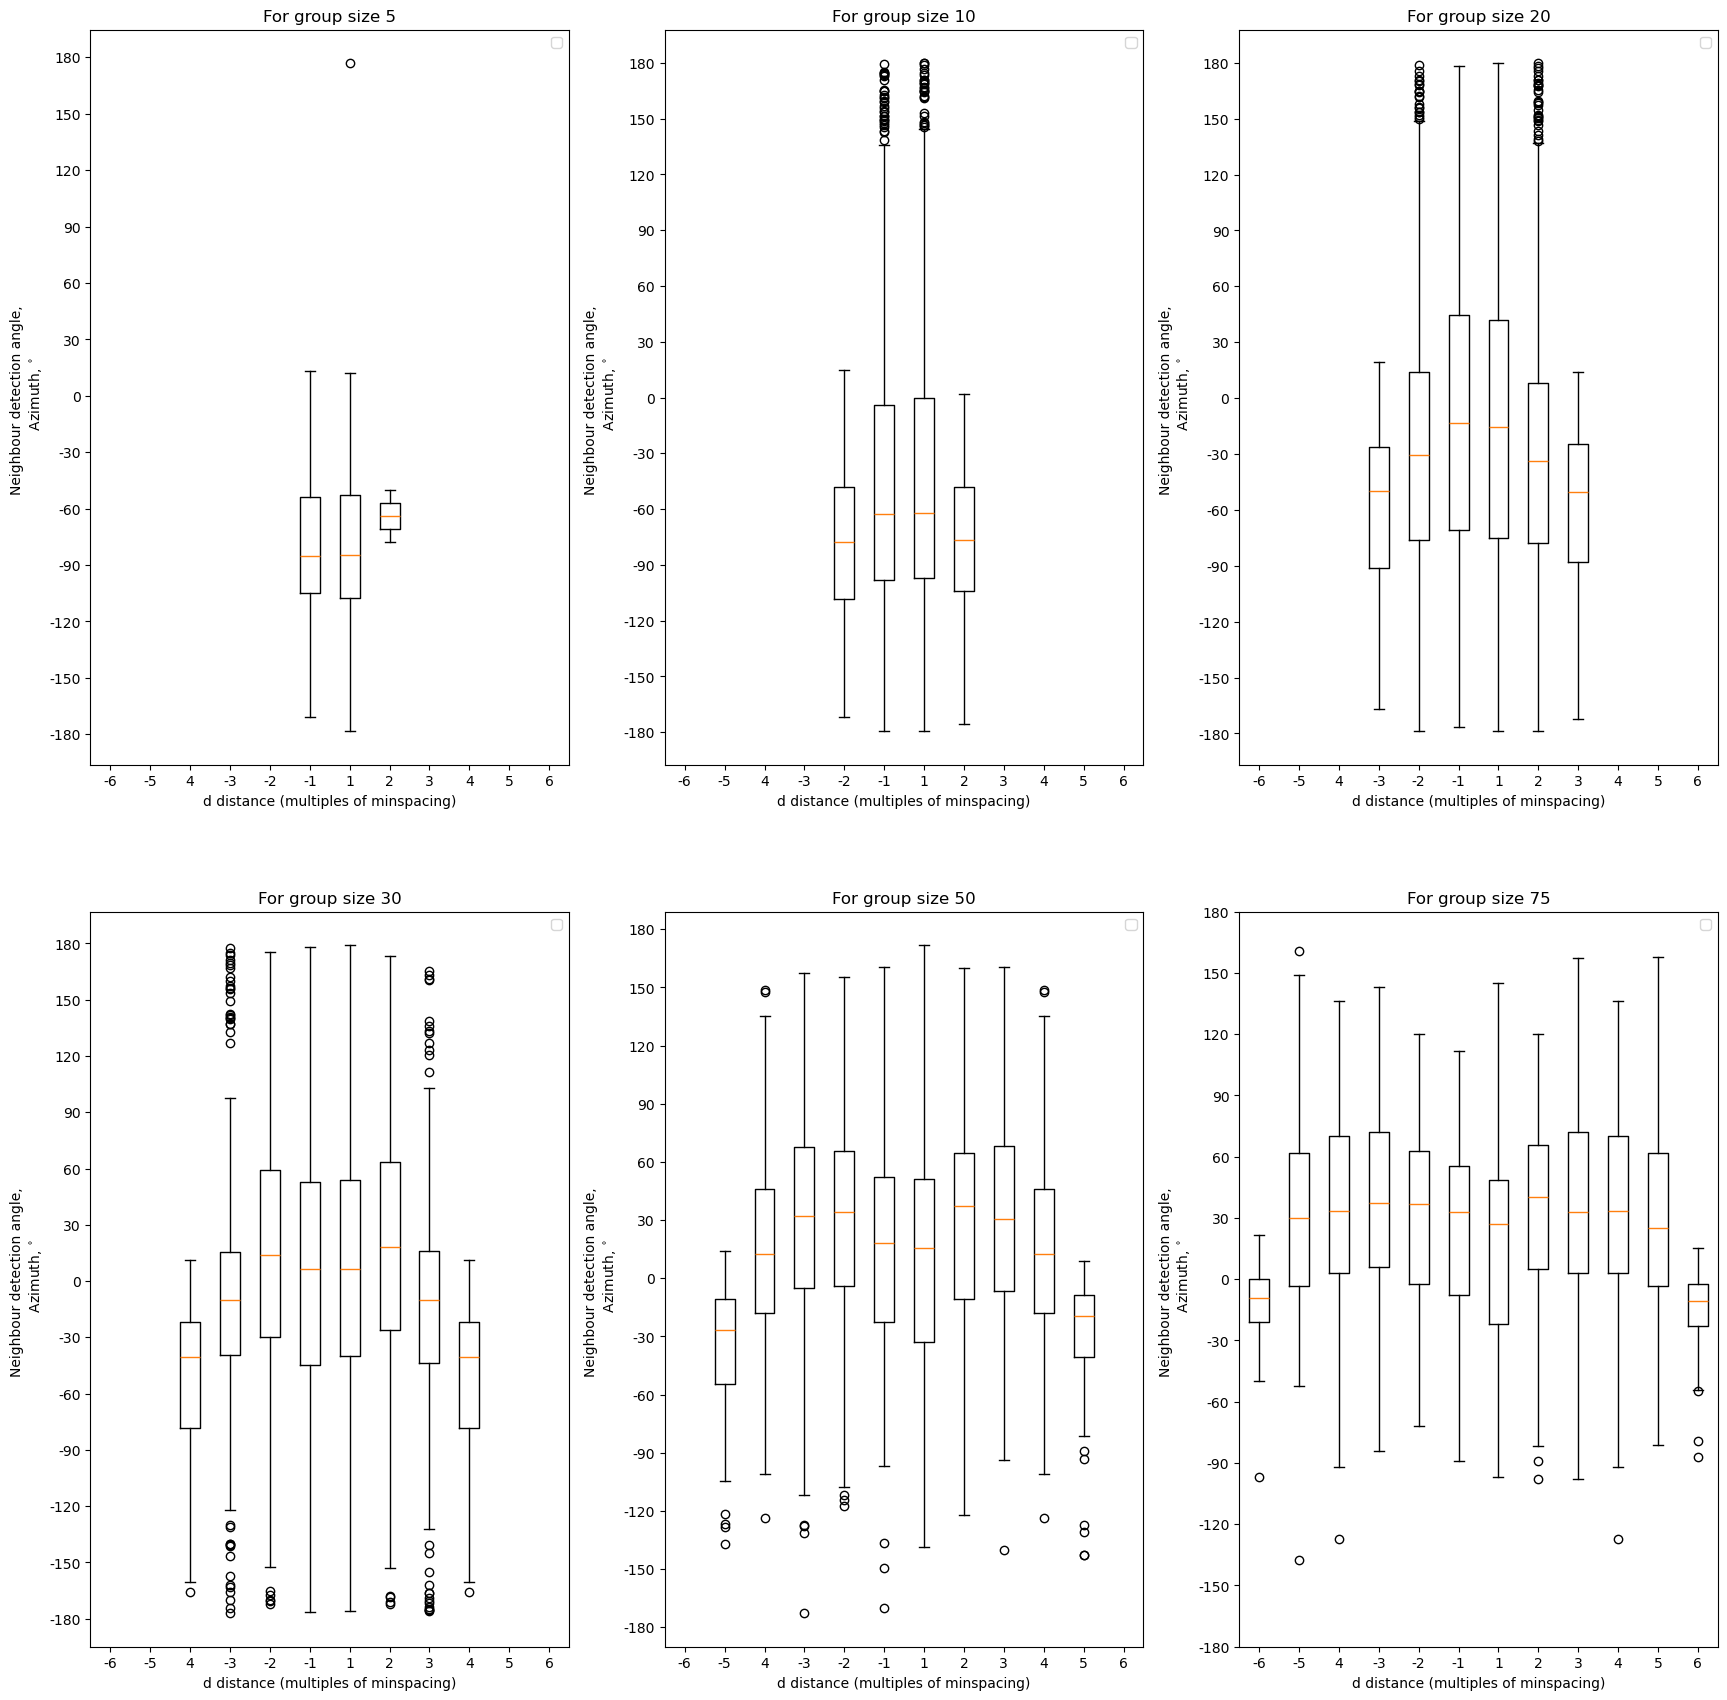

In [305]:
i=0; 
d_distances_along_transect= [-6,-5,4,-3,-2,-1,1,2,3,4,5,6]
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
for group_size in group_sizes:
        array_storing_info_for_plot= []
        iterant_sign=-1
        x_ticks=[]
        for key in d_distances_along_transect:
                iterant_sign+=1
                nbrs_detected_data= store_probability_of_detection_n_neighbour[key]
                data_to_store= nbrs_detected_data['neighbours_azimuth'][group_sizes.index(group_size)]
                array_storing_info_for_plot.append(data_to_store)
                x_ticks.append(key)

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(array_storing_info_for_plot);

        plt.yticks(np.arange(-180,210,30), np.arange(-180,210,30), fontsize=10)
        plt.xticks(np.arange(1,len(x_ticks)+1), x_ticks, fontsize=10)

        plt.ylabel('Neighbour detection angle, \n  Azimuth, $^{\circ}$', fontsize=10)
        plt.xlabel('d distance (multiples of minspacing)', fontsize=10)
        plt.title(f"For group size {group_size}")
        plt.legend()
        print(key_for_dict)
        i+=1

In [306]:
class No_situation_for_given_nd(Exception):
    """Still an exception raised when uncommon things happen"""
    def __init__(self, message, payload=None):
        self.message = message
        self.payload = payload # you could add more args
    def __str__(self):
        return str(self.message)

In [307]:
try:
    raise No_situation_for_given_nd(f"Failure to generate scenario in which there exists no point that is {1} number of step(s) away from the centermost bat")
except No_situation_for_given_nd as error:
    print(str(error)) # Very bad mistake
print("omg")

Failure to generate scenario in which there exists no point that is 1 number of step(s) away from the centermost bat
omg


In [308]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat'],
      dtype='object')

In [309]:
nbrs_detected_data.keys()

dict_keys(['group_sizes', 'num_nbrs', 'median_num_nbrs', '90%ile_num_nbrs', '0neighbours', 'geq_1neighbour', 'geq_2neighbour', 'geq_3neighbour', 'geq_4neighbour', 'detected_distances', 'median_detected_distances', '90%ile_detected_distances', 'neighbours_azimuth', 'median_neighbours_azimuth', '95%ile_neighbours_azimuth', '5%ile_neighbours_azimuth', 'echolevels', 'median_echolevels', '5%ile_echolevels', '95%ile_echolevels'])

In [310]:
nbrs_detected_data

{'group_sizes': [5, 10, 20, 30, 50, 75],
 'num_nbrs': [nan,
  nan,
  nan,
  nan,
  nan,
  array([0, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
         0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 2, 0, 1, 0, 1, 0, 0, 1, 1, 1,
         1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
         1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
         1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0])],
 'median_num_nbrs': [nan, nan, nan, nan, nan, np.float64(0.0)],
 '90%ile_num_nbrs': [nan, nan, nan, nan, nan, np.float64(1.0)],
 '0neighbours': [nan, nan, nan, nan, nan, np.float64(0.53)],
 'geq_1neighbour': [nan, nan, nan, nan, nan, np.float64(0.47)],
 'geq_2neighbour': [nan, nan, nan, nan, nan, np.float64(0.02)],
 'geq_3neighbour': [nan, nan, nan, nan, nan, np.float64(0.0)],
 'geq_4neighbour': [nan, nan, nan, nan, nan, np.float64(0.0)],
 'detected_distances': [nan,
  nan,
  nan,
  nan,
  nan,
  array([0.58745907, 0.50073516, 0.7851152 , 0.61386692, 0.52964

In [311]:
import seaborn as sns
plt.boxplot(nbrs_detected_data["group_sizes", y="detected_distances")

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (2306753847.py, line 2)